# Keşifsel Veri Analizi (EDA)
## Credit Card Fraud Detection Dataset

In [67]:
# Kütüphaneleri import et
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---
## Phase A: Veri Yükleme ve Genel Bakış

In [68]:
# Veriyi yükle
df = pd.read_csv('Data/creditcard.csv')
print(f"Veri boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri boyutu: 284807 satır, 31 sütun


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


*Veri büyük çoğunlukla PCA ile kişisel bilgiler korunmuş halde gelmiş. Yani 31 sütun'dan birinin de hedef feature olduğu da göz önünde bulundurulunca, PCA yapılmamış ve kullanılabilecek sadece 2 feature olduğunu görmüş oluyoruz.*

In [69]:
# Veri tipleri
print("=" * 50)
print("VERİ TİPLERİ")
print("=" * 50)
print(df.dtypes)
print("\n")
print("=" * 50)
print("VERİ BİLGİSİ")
print("=" * 50)
df.info()

VERİ TİPLERİ
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


VERİ BİLGİSİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non

*Veriler genel anlamda float halinde. Bir classification problemi ile karşı karşıya olduğumuz için hedef değerimiz olan Class sütununa zamanı gelince veri dönüşümü uygulanması şart. Null değer görünmediği için data cleaning'e gerek olmadığını görüyoruz.*

In [70]:
# Describe — istatistiksel özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


*PCA'lı verilerin içeriğini bilmesek de eksik veri olmadığını ve PCA olmamış featureların ise dengeli bir şekilde mean'lerini ve sınırlarını görmüş oluyoruz.*

In [71]:
# Count — her sütundaki non-null değer sayısı
print("=" * 50)
print("NON-NULL DEĞER SAYILARI")
print("=" * 50)
print(df.count())

NON-NULL DEĞER SAYILARI
Time      284807
V1        284807
V2        284807
V3        284807
V4        284807
V5        284807
V6        284807
V7        284807
V8        284807
V9        284807
V10       284807
V11       284807
V12       284807
V13       284807
V14       284807
V15       284807
V16       284807
V17       284807
V18       284807
V19       284807
V20       284807
V21       284807
V22       284807
V23       284807
V24       284807
V25       284807
V26       284807
V27       284807
V28       284807
Amount    284807
Class     284807
dtype: int64


In [72]:
# Tüm feature'ların mean değerleri
print("=" * 50)
print("TÜM FEATURE'LARIN MEAN DEĞERLERİ")
print("=" * 50)
mean_values = df.mean()
for col, val in mean_values.items():
    print(f"{col:>20s}: {val:>15.6f}")

TÜM FEATURE'LARIN MEAN DEĞERLERİ
                Time:    94813.859575
                  V1:        0.000000
                  V2:        0.000000
                  V3:       -0.000000
                  V4:        0.000000
                  V5:        0.000000
                  V6:        0.000000
                  V7:       -0.000000
                  V8:        0.000000
                  V9:       -0.000000
                 V10:        0.000000
                 V11:        0.000000
                 V12:       -0.000000
                 V13:        0.000000
                 V14:        0.000000
                 V15:        0.000000
                 V16:        0.000000
                 V17:       -0.000000
                 V18:        0.000000
                 V19:        0.000000
                 V20:        0.000000
                 V21:        0.000000
                 V22:       -0.000000
                 V23:        0.000000
                 V24:        0.000000
                 

In [73]:
# Eksik veri tespiti
print("=" * 50)
print("EKSİK VERİ TESPİTİ")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Eksik Adet': missing, 'Eksik Yüzde (%)': missing_pct})
missing_df = missing_df.sort_values('Eksik Adet', ascending=False)
print(missing_df)
print(f"\nToplam eksik veri sayısı: {df.isnull().sum().sum()}")

EKSİK VERİ TESPİTİ
        Eksik Adet  Eksik Yüzde (%)
Time             0              0.0
V1               0              0.0
V2               0              0.0
V3               0              0.0
V4               0              0.0
V5               0              0.0
V6               0              0.0
V7               0              0.0
V8               0              0.0
V9               0              0.0
V10              0              0.0
V11              0              0.0
V12              0              0.0
V13              0              0.0
V14              0              0.0
V15              0              0.0
V16              0              0.0
V17              0              0.0
V18              0              0.0
V19              0              0.0
V20              0              0.0
V21              0              0.0
V22              0              0.0
V23              0              0.0
V24              0              0.0
V25              0              0.0
V26      

In [74]:
# Amount = 0 olan satırlar
amount_zero = df[df['Amount'] == 0]
print(f"Amount değeri 0 olan satır sayısı: {len(amount_zero)}")
print(f"Toplam verinin %{len(amount_zero)/len(df)*100:.2f}'i")
print(f"\nBu satırların Class dağılımı:")
print(amount_zero['Class'].value_counts())

Amount değeri 0 olan satır sayısı: 1825
Toplam verinin %0.64'i

Bu satırların Class dağılımı:
Class
0    1798
1      27
Name: count, dtype: int64


*Burası biraz önemli. Neticede, bir kredi kartı harcaması eğer kayda geçiyorsa 0 olmamalı. Ancak hem gözardı edilebilir bir oranda olması hem de verinin nasıl elde edildiğini tam olarak bilemediğimiz için, kalmasında bir problem olmadığını düşünmekteyim.*

In [75]:
# Time = 0 olan satırlar
time_zero = df[df['Time'] == 0]
print(f"Time değeri 0 olan satır sayısı: {len(time_zero)}")
print(f"Toplam verinin %{len(time_zero)/len(df)*100:.4f}'i")
print(f"\nBu satırların Class dağılımı:")
print(time_zero['Class'].value_counts())

Time değeri 0 olan satır sayısı: 2
Toplam verinin %0.0007'i

Bu satırların Class dağılımı:
Class
0    2
Name: count, dtype: int64


In [76]:
# Class feature'ında 0 veya 1'den başka değer var mı?
unique_classes = df['Class'].unique()
print(f"Class sütunundaki unique değerler: {sorted(unique_classes)}")
print(f"Unique değer sayısı: {df['Class'].nunique()}")

non_standard = df[~df['Class'].isin([0, 1])]
print(f"\n0 ve 1 dışında değer içeren satır sayısı: {len(non_standard)}")
if len(non_standard) > 0:
    print("DİKKAT: 0 ve 1 dışında değerler tespit edildi!")
    print(non_standard['Class'].value_counts())
else:
    print("Class sütununda sadece 0 ve 1 değerleri mevcut.")

Class sütunundaki unique değerler: [np.int64(0), np.int64(1)]
Unique değer sayısı: 2

0 ve 1 dışında değer içeren satır sayısı: 0
Class sütununda sadece 0 ve 1 değerleri mevcut.


---
## Phase B: Sınıf Dağılımı ve Imbalance Oranı

In [77]:
# Fraud vs Non-Fraud sınıf dağılımı
class_counts = df['Class'].value_counts()
print("=" * 50)
print("SINIF DAĞILIMI")
print("=" * 50)
print(f"Non-Fraud (0): {class_counts[0]:>10,}  ({class_counts[0]/len(df)*100:.4f}%)")
print(f"Fraud     (1): {class_counts[1]:>10,}  ({class_counts[1]/len(df)*100:.4f}%)")
print(f"\nImbalance Oranı (Non-Fraud / Fraud): {class_counts[0] / class_counts[1]:.2f} : 1")
print(f"Fraud Oranı: %{class_counts[1]/len(df)*100:.4f}")

SINIF DAĞILIMI
Non-Fraud (0):    284,315  (99.8273%)
Fraud     (1):        492  (0.1727%)

Imbalance Oranı (Non-Fraud / Fraud): 577.88 : 1
Fraud Oranı: %0.1727


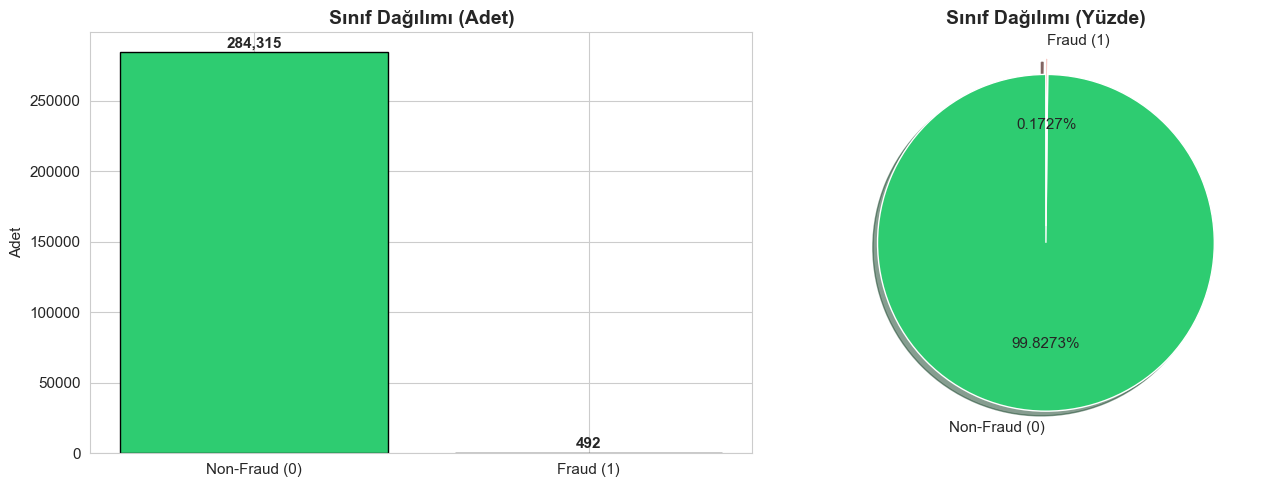

In [78]:
# Sınıf dağılımı bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Sınıf Dağılımı (Adet)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Adet')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Fraud (0)', 'Fraud (1)'],
            autopct='%1.4f%%', colors=colors, startangle=90,
            explode=(0, 0.1), shadow=True)
axes[1].set_title('Sınıf Dağılımı (Yüzde)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

*Bu oranlar aşırı dengesiz, inbalanced veriyi göstermekte. Veri dengelenmeli, az sayıda olan sınıf desteklenmeli ki her tahminde non-fraud yönünde bir tahmin yapmasın. Bizim zaten amacımız non-fraud olanları yakalamaktansa fraud olanları tespit edip yakalamak.*

---
## Phase C: Amount ve Time Dağılımları (Fraud vs Normal)

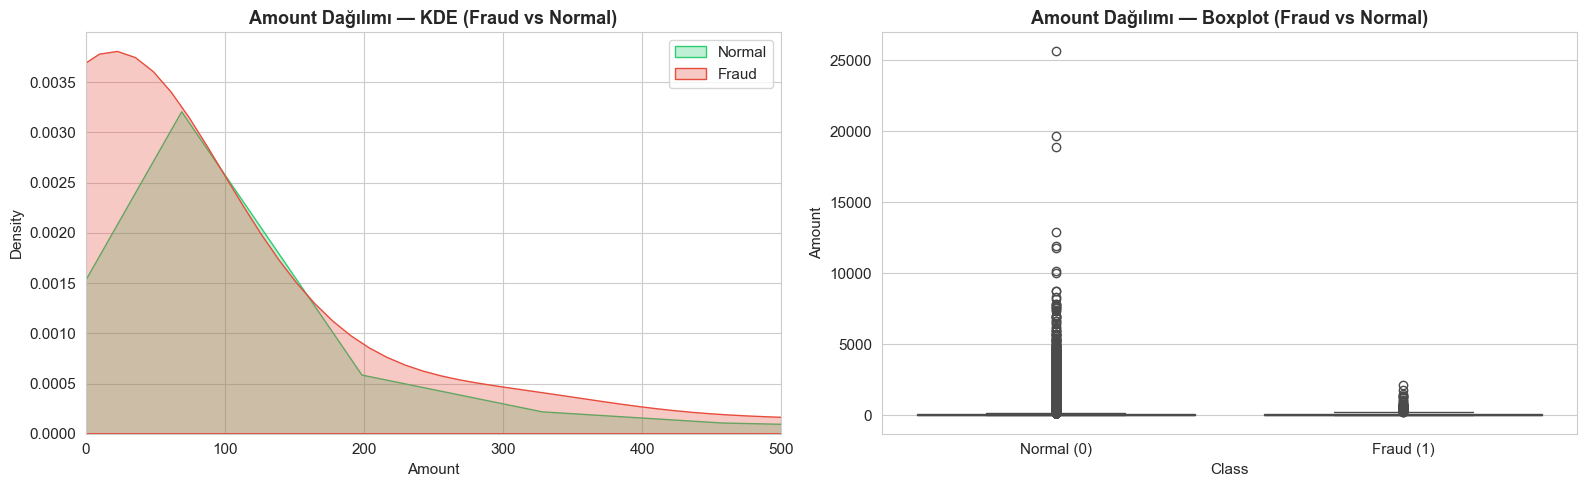

In [79]:
# Amount — KDE Plot (Fraud vs Normal)
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE
sns.kdeplot(normal['Amount'], ax=axes[0], label='Normal', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(fraud['Amount'], ax=axes[0], label='Fraud', color='#e74c3c', fill=True, alpha=0.3)
axes[0].set_title('Amount Dağılımı — KDE (Fraud vs Normal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_xlim(0, 500)  # Çoğu değer bu aralıkta
axes[0].legend()

# Boxplot
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1], palette=colors)
axes[1].set_title('Amount Dağılımı — Boxplot (Fraud vs Normal)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

*Sadece bu grafiğe bakarak, miktar arttıkça fraud da normal de yoğunluk olarak azalmış gibi görüyoruz. Normal'in genellikle belli aralıklara dağıldığını, tahmini amount değeri olarak 100'ün çevresinde bulunduğunu, daha az miktarların belli ölçüde fraud tarafta daha çok öne çıktığını görüyoruz. Tabii, fraud'un az sayıda olduğunun altını çizmekte fayda var.*

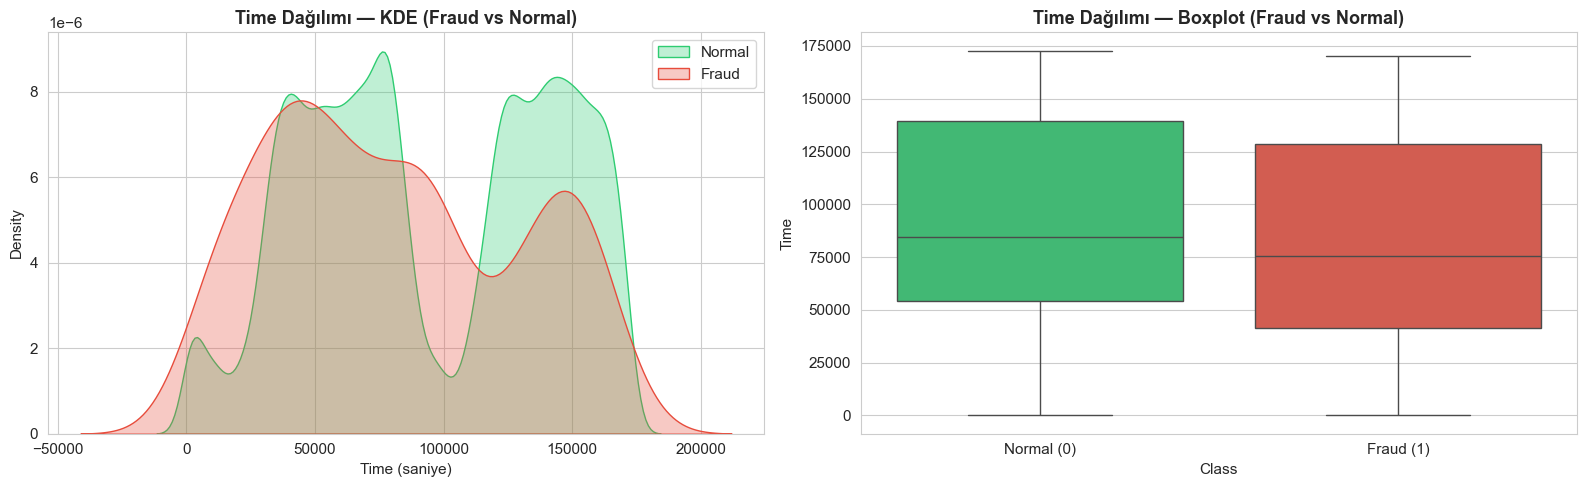

In [80]:
# Time — KDE Plot (Fraud vs Normal)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE
sns.kdeplot(normal['Time'], ax=axes[0], label='Normal', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(fraud['Time'], ax=axes[0], label='Fraud', color='#e74c3c', fill=True, alpha=0.3)
axes[0].set_title('Time Dağılımı — KDE (Fraud vs Normal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (saniye)')
axes[0].legend()

# Boxplot
sns.boxplot(x='Class', y='Time', data=df, ax=axes[1], palette=colors)
axes[1].set_title('Time Dağılımı — Boxplot (Fraud vs Normal)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

*Bu grafiğe göre Fraud'ların kısa sürede daha sık ve belli aralıklarda yüksek olduğunu görüyoruz. Ancak normallerin de peak yaptığı noktalar aynı saniye aralıklarında olduğu için fraud tespitinin zor olması son derece olağan. Yani yoğunluk olarak farklı olsalar da görüldüğü üzere peak yaptıkları noktalar ve azaldıkları noktalar birbirlerinden çok ötelenmiş değil. Ortalama olarak yakın oldukları da box plotlarda gözükmekte. Fakat normal aralığın ortalamasının bir tık daha daha yüksek saniyelerde yani daha uzun zaman aralıklarında yapıldığını görebiliriz.*

---
## Phase D: PCA Feature Dağılımları (Fraud vs Normal) — V1 - V28

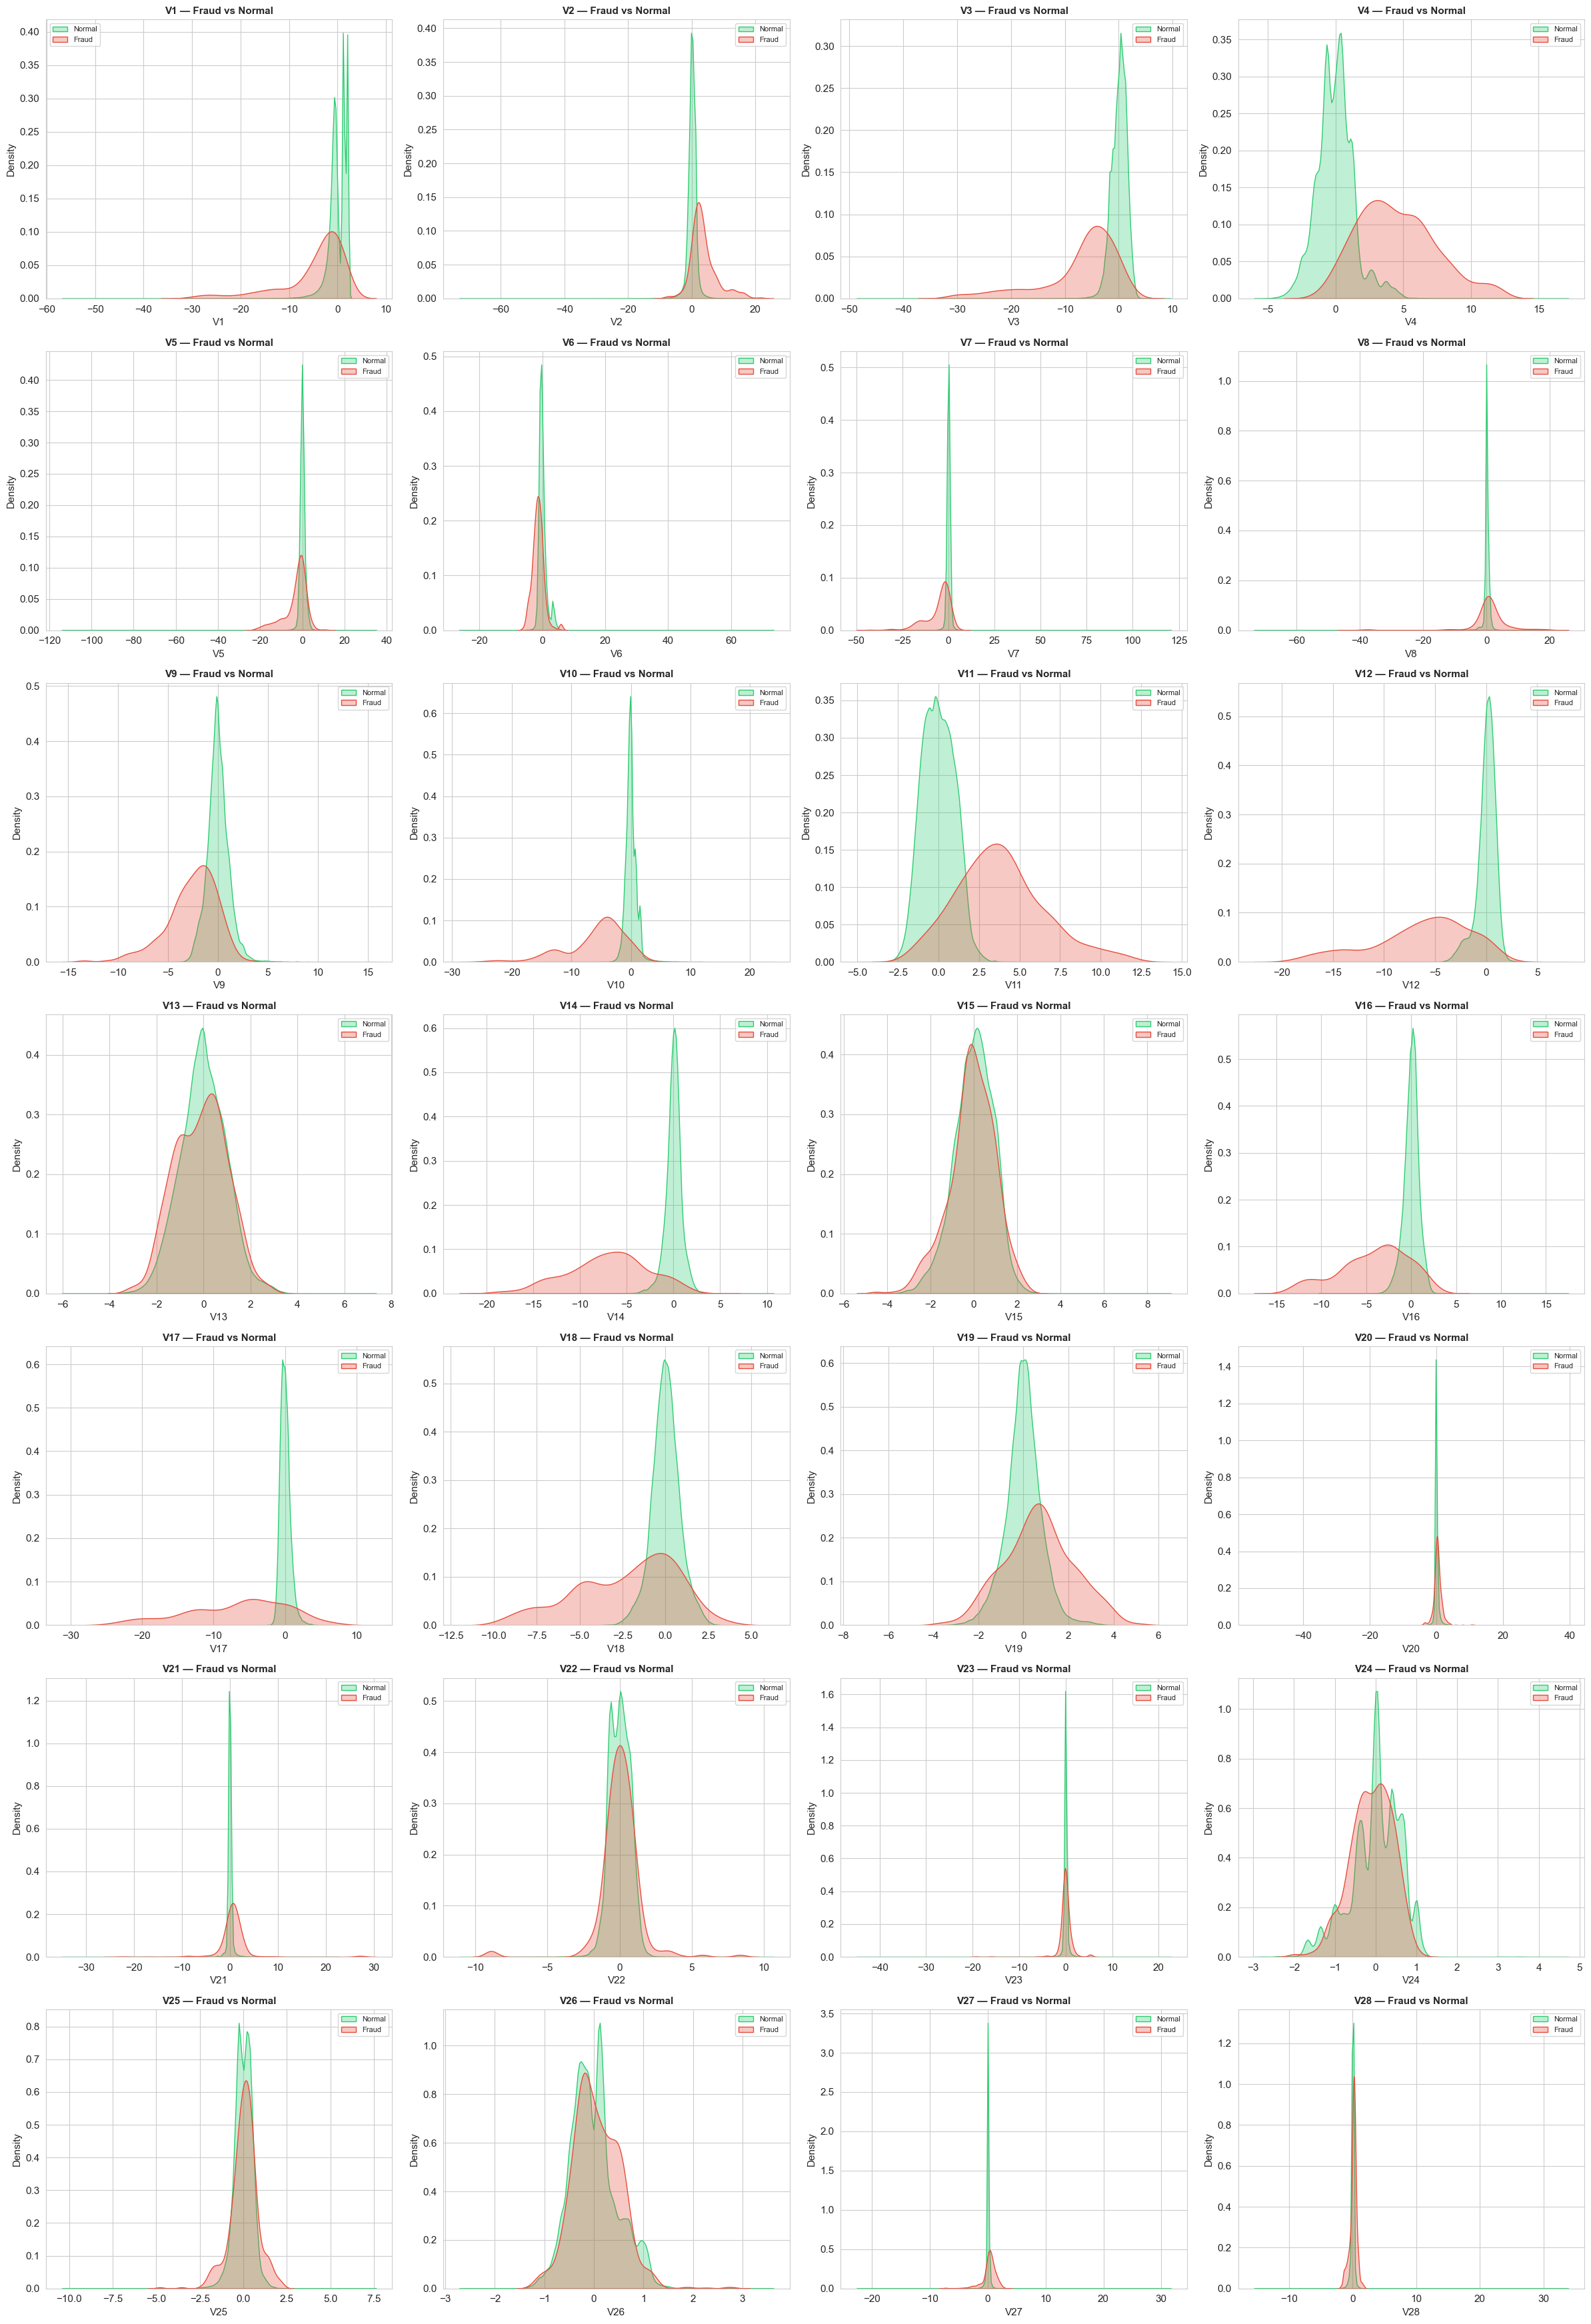

In [81]:
# V1-V28 KDE plotları — Fraud vs Normal
pca_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(24, 35))
axes = axes.flatten()

for i, col in enumerate(pca_features):
    sns.kdeplot(normal[col], ax=axes[i], label='Normal', color='#2ecc71', fill=True, alpha=0.3)
    sns.kdeplot(fraud[col], ax=axes[i], label='Fraud', color='#e74c3c', fill=True, alpha=0.3)
    axes[i].set_title(f'{col} — Fraud vs Normal', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

*V1,V2,V3,V5,V6,V7,V8,V9,V10, V20,V21,V23 ve V27'nin örtüştüğünü ancak yoğunluk olarak uzak olduğunu görüyoruz.Yani dağılım trendsel olarak aynı ama sık görülmesi tamamen zıt olabiliyor. Ancak V25, V26 ve V28'in hem neredeyse örtüştüğünü hem de hem de yoğunluk olarak yakın olduklarını görüyoruz. Yani bu featureların etkileri hakkında öngörüde bulunmak konusunda katkı sağlayabilir, çünkü PCA'lı feature'ın PCA'sını biz yapmadığımız için içeriğini tam bilmiyoruz. Ancak benim nezimde, özellikle bahsetmediğim yani birbirlerine çok örtüşmeyen veya yoğunluk farkı da dengeli olduğundan fraud ya da fraud olmayanın tespitinde daha yardımcı olacaklarını düşünmekteyim.*

---
## Phase E: Tüm Feature'lar İçin Dağılım Grafikleri

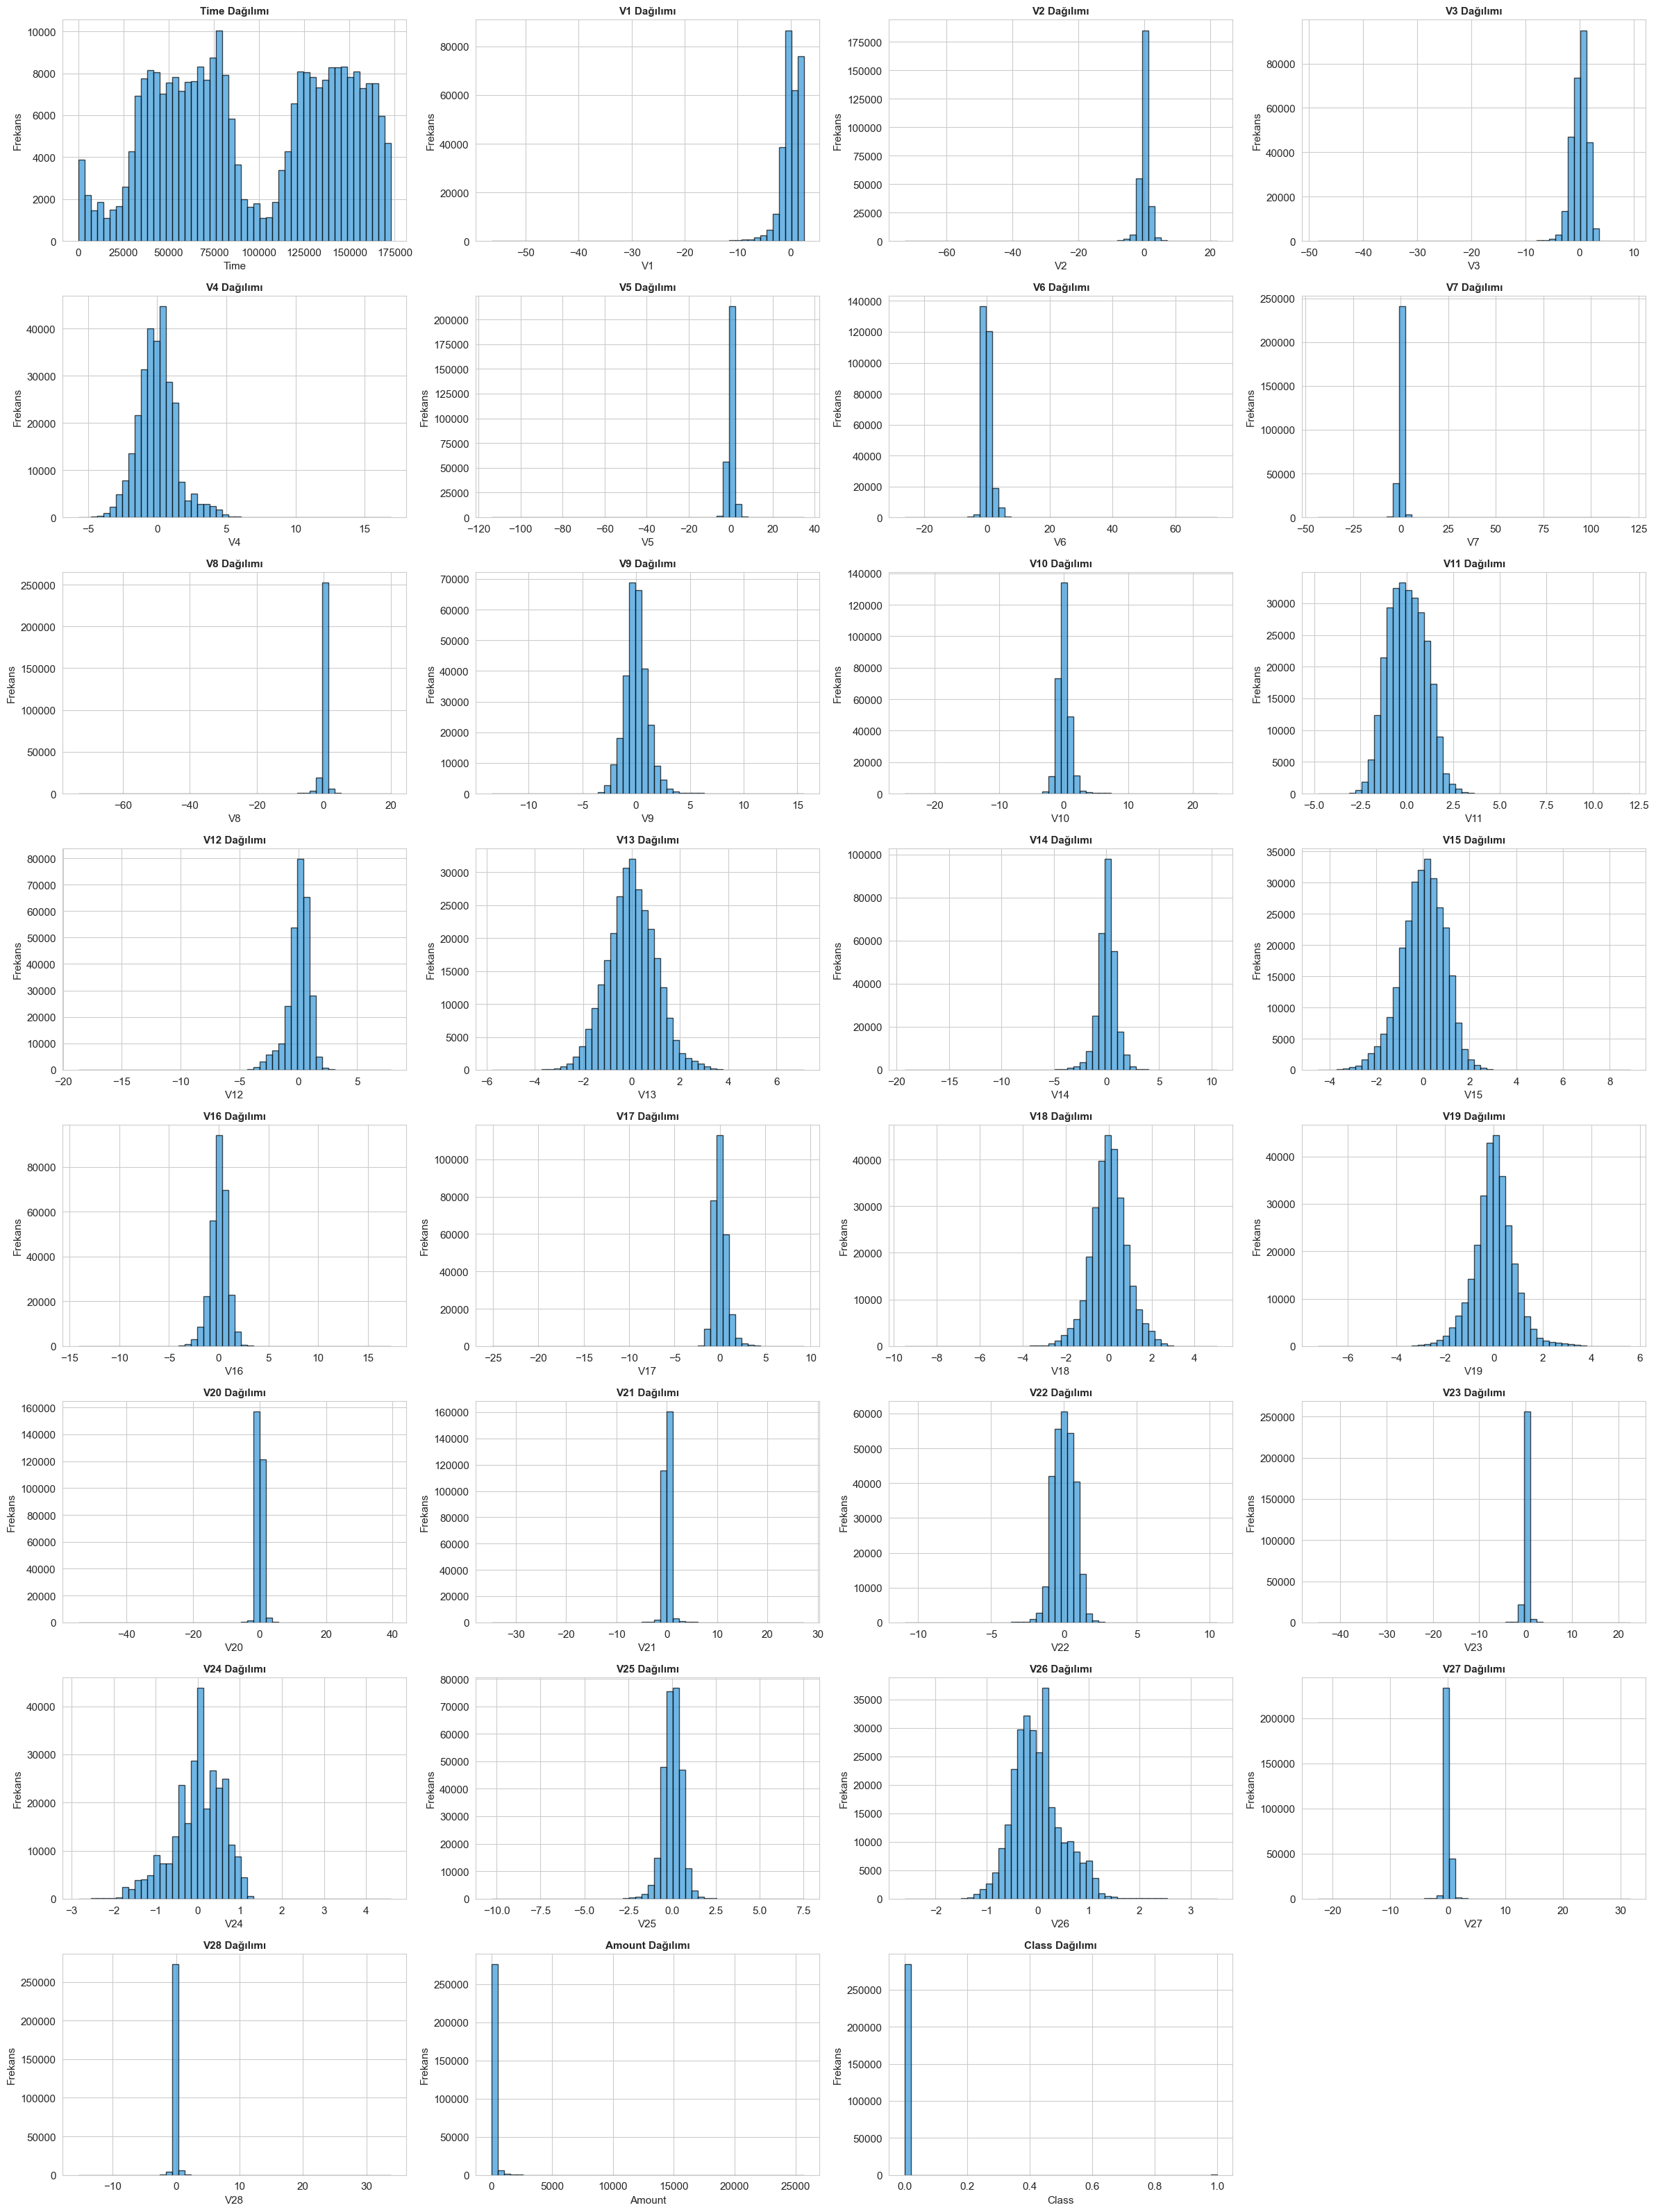

In [82]:
# Tüm feature'lar için histogram dağılım grafikleri
all_features = df.columns.tolist()
n_features = len(all_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(all_features):
    axes[i].hist(df[col], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Dağılımı', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')

# Boş subplot'ları gizle
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

*Genel olarak dağılımların dengeli olduğunu ve ortalama değerleri çok iyi görebiliyoruz. Ancak Time feature'ının dağılımında iki tane peak ve iki çukur olduğunu, böylelikle diğer featureların aksine bazı noktalarda düşüp bazı noktalarda arttığını gördüğümüzü bu yüzden sabit bir ortalama(mean) vermenin doğru olmayacağını söyleyebiliriz.*

---
## Phase F: Korelasyon Matrisi (Heatmap)

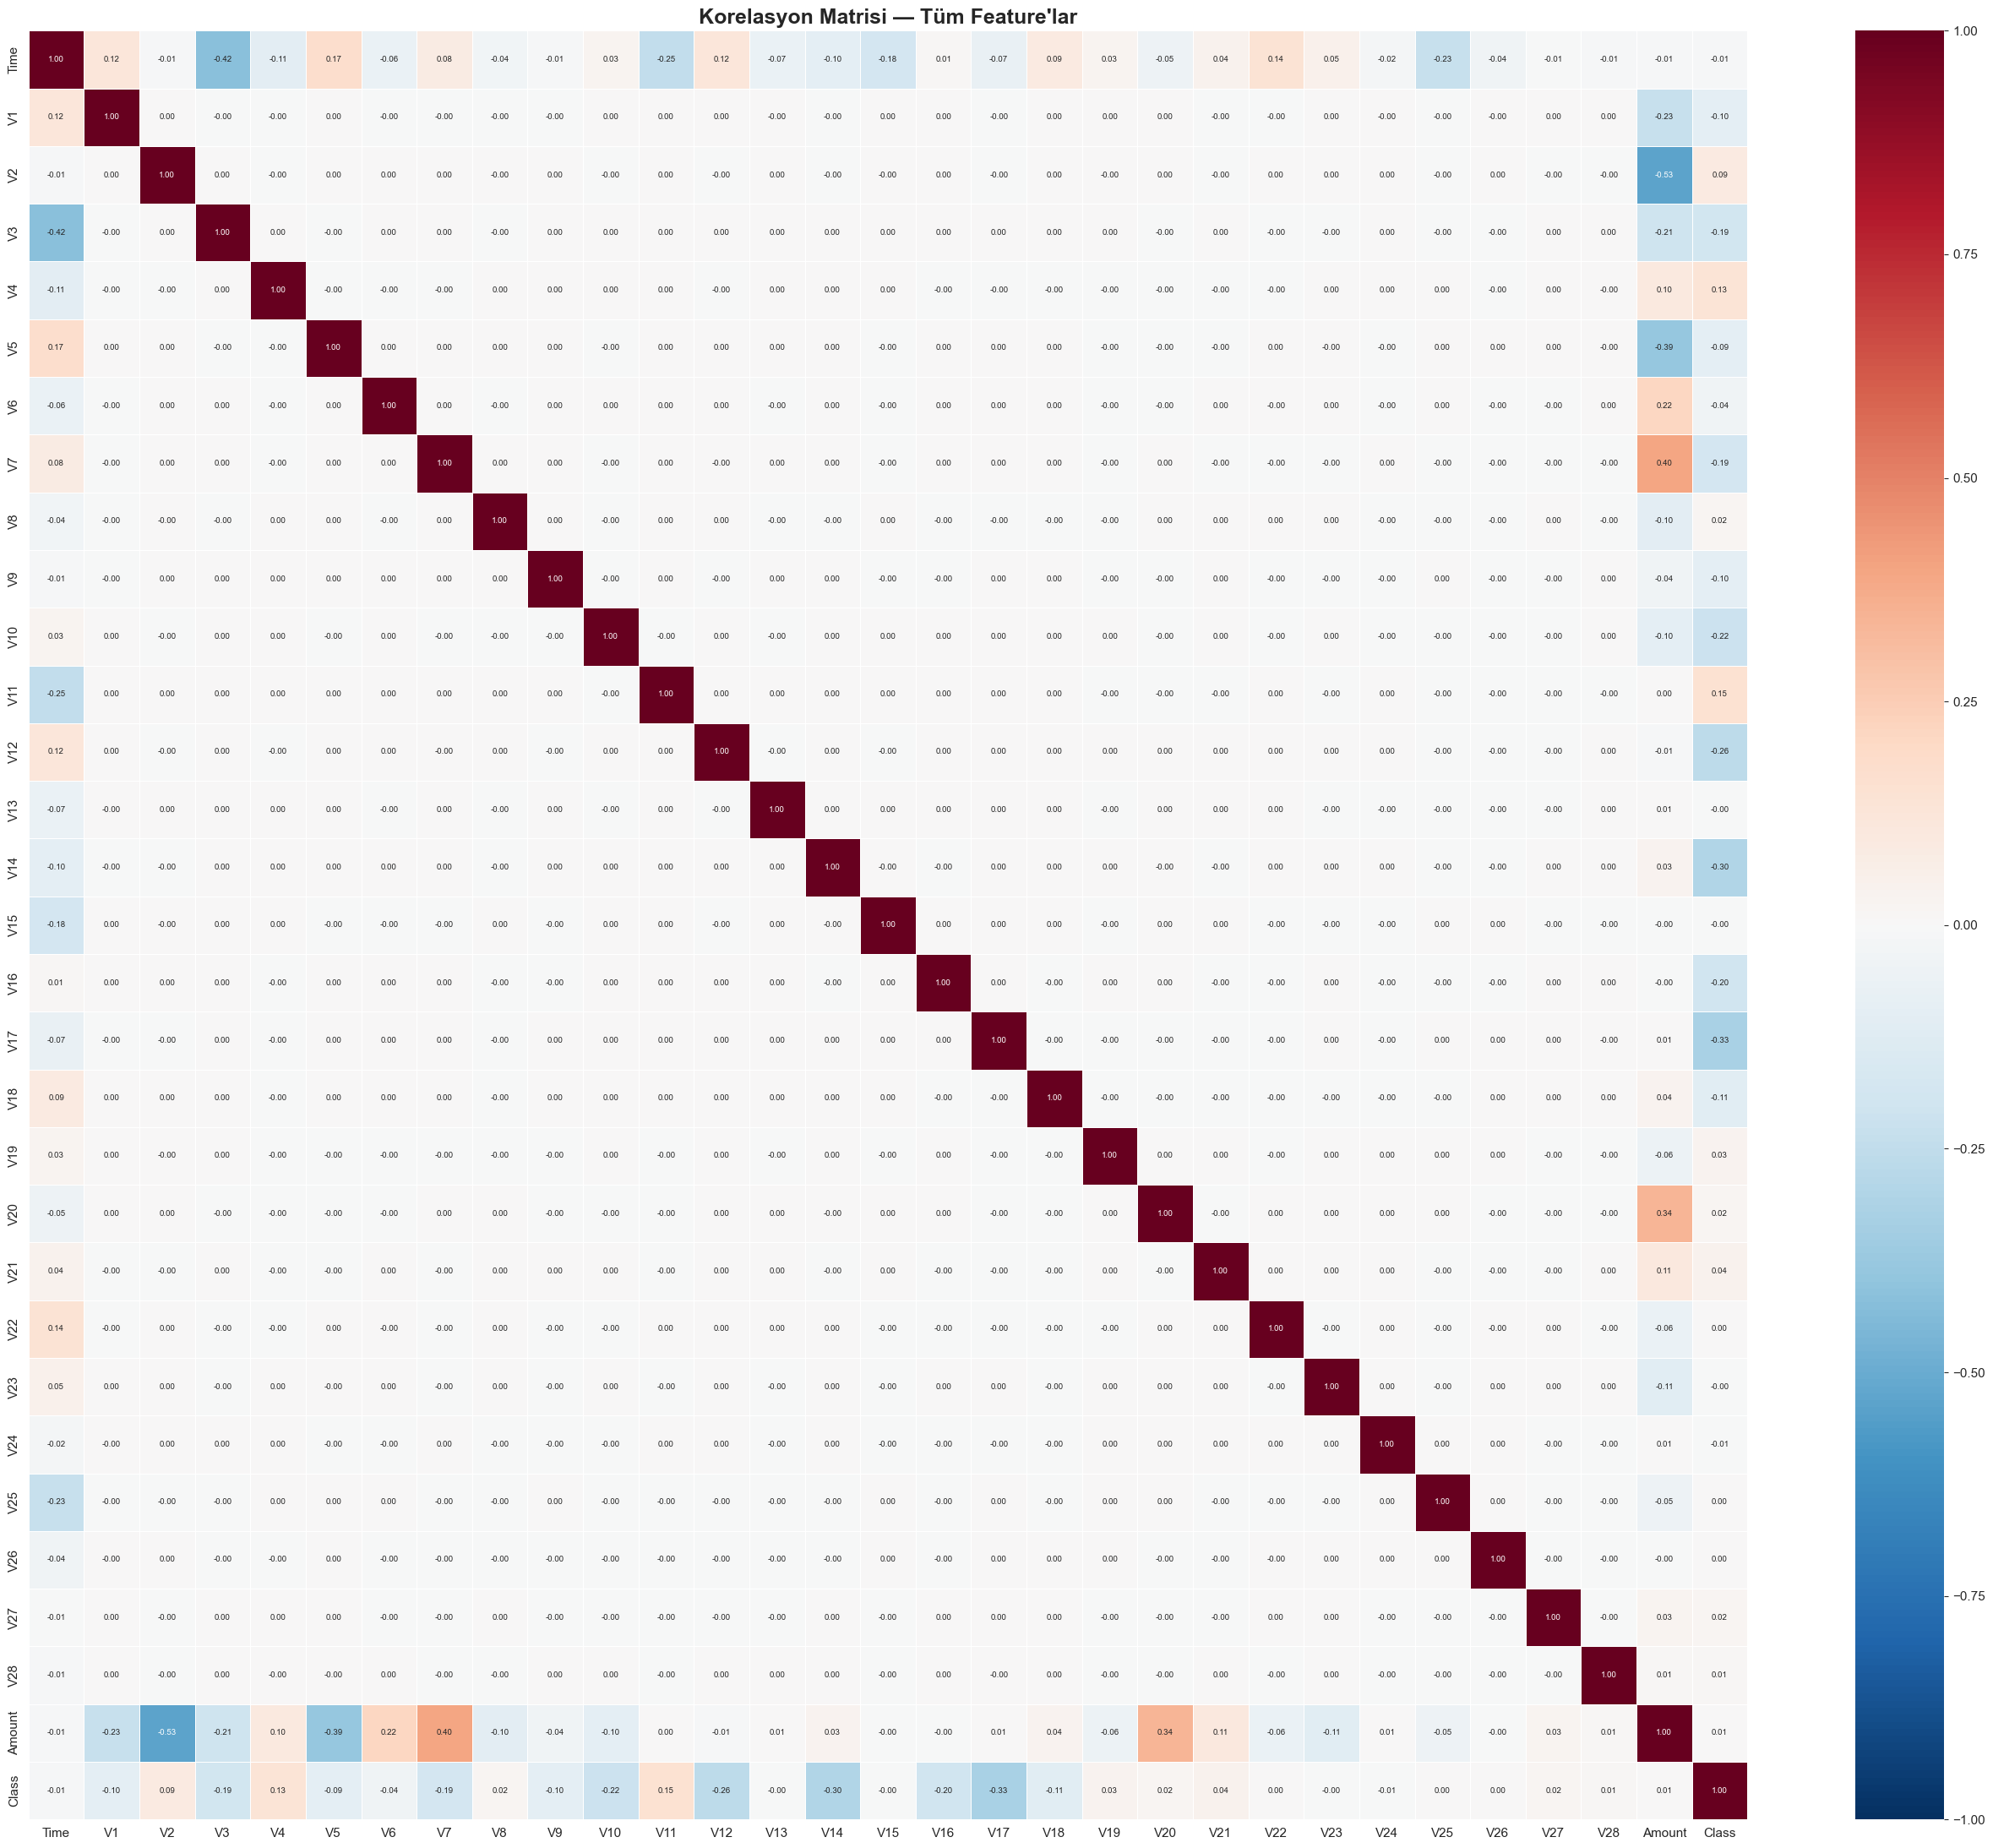

In [83]:
# Korelasyon matrisi heatmap
corr_matrix = df.corr()

plt.figure(figsize=(26, 22))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
plt.title('Korelasyon Matrisi — Tüm Feature\'lar', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

*Ne 0.85 ne de -0.85'in altında veya yakınında hiçbir değer olmaması, veri featurelarının hiçbirinin birbiriyle negatif ya da pozitif anlamda aşırı yüksek korelasyonu olmadığını bun da hiçbir feature'ın anlamsız ya da tekrarlayan bir sütun olmadığını görüyoruz. Yani modelimizde hepsini kullanmak modelimizi iyileştirecektir.*

CLASS İLE KORELASYONU EN YÜKSEK İLK 5 FEATURE
       V17: -0.3265
       V14: -0.3025
       V12: -0.2606
       V10: -0.2169
       V16: -0.1965


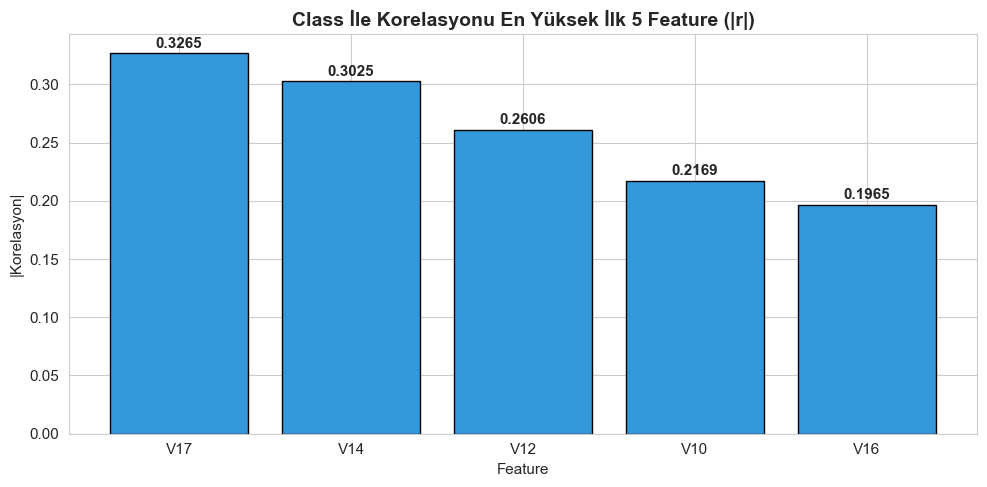

In [84]:
# Class ile korelasyonu en yüksek ilk 5 feature
class_corr = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
top5_corr = class_corr.head(5)

print("=" * 50)
print("CLASS İLE KORELASYONU EN YÜKSEK İLK 5 FEATURE")
print("=" * 50)
for feat, val in top5_corr.items():
    direction = '+' if corr_matrix['Class'][feat] > 0 else '-'
    print(f"{feat:>10s}: {direction}{val:.4f}")

# Bar chart
plt.figure(figsize=(10, 5))
colors_corr = ['#e74c3c' if corr_matrix['Class'][f] > 0 else '#3498db' for f in top5_corr.index]
plt.bar(top5_corr.index, top5_corr.values, color=colors_corr, edgecolor='black')
plt.title('Class İle Korelasyonu En Yüksek İlk 5 Feature (|r|)', fontsize=14, fontweight='bold')
plt.ylabel('|Korelasyon|')
plt.xlabel('Feature')
for i, (feat, val) in enumerate(top5_corr.items()):
    plt.text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase G: Fraud İşlemlerinin Zaman İçindeki Dağılımı

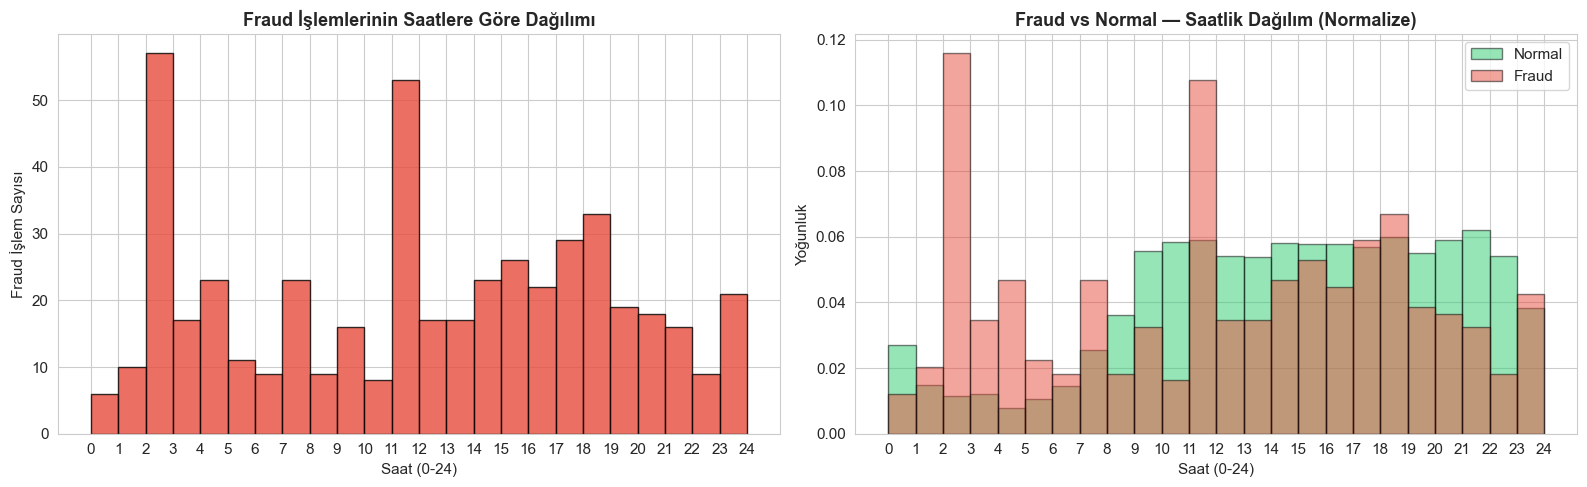

In [85]:
# Günlük döngü içindeki saat (görselleştirme amaçlı)
df['Hour'] = (df['Time'] % 86400) / 3600

fraud_hour = df[df['Class'] == 1]['Hour']
normal_hour = df[df['Class'] == 0]['Hour']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud işlemlerinin saatlere göre dağılımı
axes[0].hist(fraud_hour, bins=24, range=(0, 24), color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('Fraud İşlemlerinin Saatlere Göre Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Saat (0-24)')
axes[0].set_ylabel('Fraud İşlem Sayısı')
axes[0].set_xticks(range(0, 25))

# Fraud vs Normal karşılaştırma (normalize edilmiş)
axes[1].hist(normal_hour, bins=24, range=(0, 24), color='#2ecc71', alpha=0.5,
             edgecolor='black', label='Normal', density=True)
axes[1].hist(fraud_hour, bins=24, range=(0, 24), color='#e74c3c', alpha=0.5,
             edgecolor='black', label='Fraud', density=True)
axes[1].set_title('Fraud vs Normal — Saatlik Dağılım (Normalize)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saat (0-24)')
axes[1].set_ylabel('Yoğunluk')
axes[1].set_xticks(range(0, 25))
axes[1].legend()

plt.tight_layout()
plt.show()

# Geçici sütunu kaldır
df.drop('Hour', axis=1, inplace=True)

*Baktığımızda genellikle sabahları fraud sayısının, öğleden sonraya kıyasla daha az sayıda olduğuunu, sadece bu veri özelinde sabah 2 ve öğlen 12'de anormal derecede artarak peak olduğunu görüyoruz. Normal ile üst üste koyarak normalize edersek de, Sabah 01.00-08.00 arasında ve 17.00-18.00 ve gece 12 civarı fraud'un normalin üstünde olduğunu, geri kalanlarda çoğunlukla normalin daha yüksek olduğunu görüyoruz. Bu da aslında, 12 gibi çalışanların öğle yemeği arası verdiğini varsaydığımızda, çalışma saatlerinin dışında fraud denemelerinin daha yüksek olduğunu görüyoruz.*

---
## Phase H: Outlier Analizi

In [86]:
# Amount için IQR tabanlı outlier tespiti
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_amount = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print("=" * 50)
print("AMOUNT — IQR TABANLI OUTLIER ANALİZİ")
print("=" * 50)
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Alt Sınır: {lower_bound:.2f}")
print(f"Üst Sınır: {upper_bound:.2f}")
print(f"\nOutlier sayısı: {len(outliers_amount):,}")
print(f"Toplam verinin %{len(outliers_amount)/len(df)*100:.2f}'i")
print(f"\nOutlier'ların Class dağılımı:")
print(outliers_amount['Class'].value_counts())

AMOUNT — IQR TABANLI OUTLIER ANALİZİ
Q1: 5.60
Q3: 77.16
IQR: 71.56
Alt Sınır: -101.75
Üst Sınır: 184.51

Outlier sayısı: 31,904
Toplam verinin %11.20'i

Outlier'ların Class dağılımı:
Class
0    31813
1       91
Name: count, dtype: int64


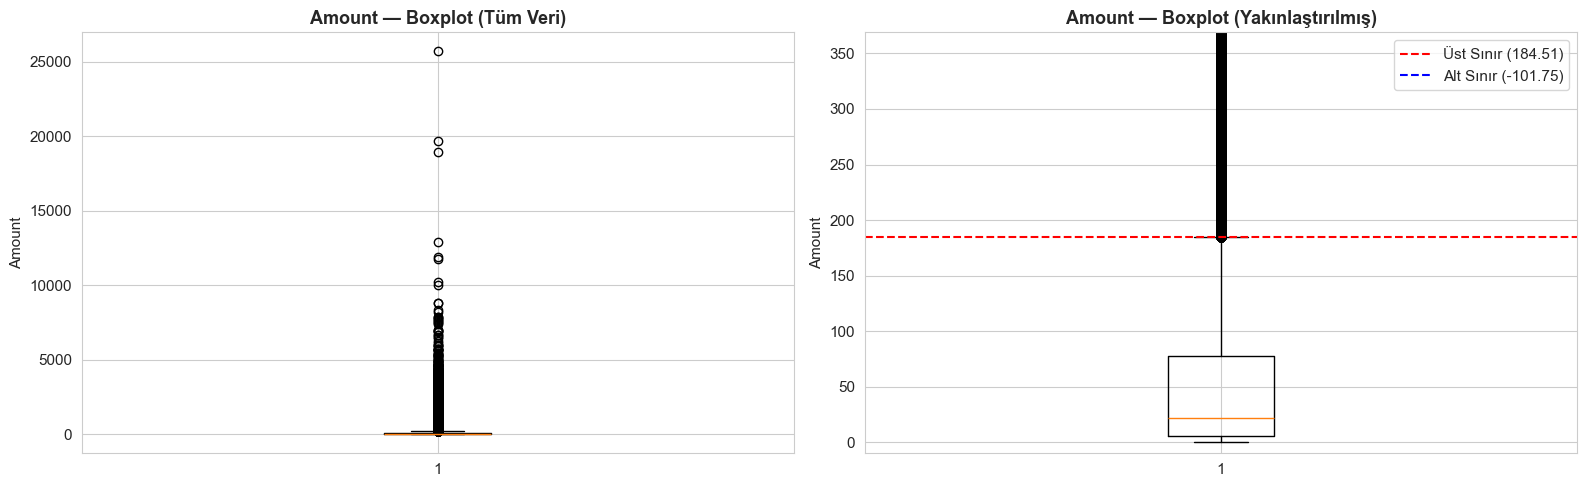

In [87]:
# Amount outlier box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot(df['Amount'], vert=True)
axes[0].set_title('Amount — Boxplot (Tüm Veri)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount')

# Upper bound'a kadar zoom
axes[1].boxplot(df['Amount'], vert=True)
axes[1].set_ylim(-10, upper_bound * 2)
axes[1].axhline(y=upper_bound, color='red', linestyle='--', label=f'Üst Sınır ({upper_bound:.2f})')
axes[1].axhline(y=lower_bound, color='blue', linestyle='--', label=f'Alt Sınır ({lower_bound:.2f})')
axes[1].set_title('Amount — Boxplot (Yakınlaştırılmış)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount')
axes[1].legend()

plt.tight_layout()
plt.show()

*Üst sınırın genellikle üstünde çok para gönderildiğini görüyoruz. Ancak bunu fraud ile bağdaştırmak yanlış olur, outlier demek de yanlış olur. Neticede yapılan harcama/göndermelerin büyük bir çoğunluğunun orta gelir tarafından yapılıyor olsa da düşük gelir ve yüksek gelir dağılımlarını bilmediğimiz için bir yorum yapmak çok anlamlı olmaz.*

In [88]:
# PCA feature'ları (V1-V28) için IQR tabanlı outlier tespiti
pca_features = [f'V{i}' for i in range(1, 29)]
outlier_summary = []

for col in pca_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    n_outliers = len(df[(df[col] < lb) | (df[col] > ub)])
    pct = n_outliers / len(df) * 100
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 4),
        'Q3': round(q3, 4),
        'IQR': round(iqr, 4),
        'Alt Sınır': round(lb, 4),
        'Üst Sınır': round(ub, 4),
        'Outlier Adet': n_outliers,
        'Outlier %': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values('Outlier Adet', ascending=False)
print("=" * 80)
print("PCA FEATURE'LARI (V1-V28) — IQR TABANLI OUTLIER TABLOSU")
print("=" * 80)
outlier_df

PCA FEATURE'LARI (V1-V28) — IQR TABANLI OUTLIER TABLOSU


,Feature,Q1,Q3,IQR,Alt Sınır,Üst Sınır,Outlier Adet,Outlier %
26,V27,-0.0708,0.0910,0.1619,-0.3137,0.3339,39163,13.75
27,V28,-0.0530,0.0783,0.1312,-0.2498,0.2751,30342,10.65
19,V20,-0.2117,0.1330,0.3448,-0.7289,0.6502,27770,9.75
7,V8,-0.2086,0.3273,0.5360,-1.0126,1.1313,24134,8.47
5,V6,-0.7683,0.3986,1.1669,-2.5186,2.1489,22965,8.06
22,V23,-0.1618,0.1476,0.3095,-0.6261,0.6119,18541,6.51
11,V12,-0.4056,0.6182,1.0238,-1.9413,2.1540,15348,5.39
20,V21,-0.2284,0.1864,0.4148,-0.8506,0.8085,14497,5.09
13,V14,-0.4256,0.4931,0.9187,-1.8037,1.8712,14149,4.97
1,V2,-0.5985,0.8037,1.4023,-2.7020,2.9071,13526,4.75


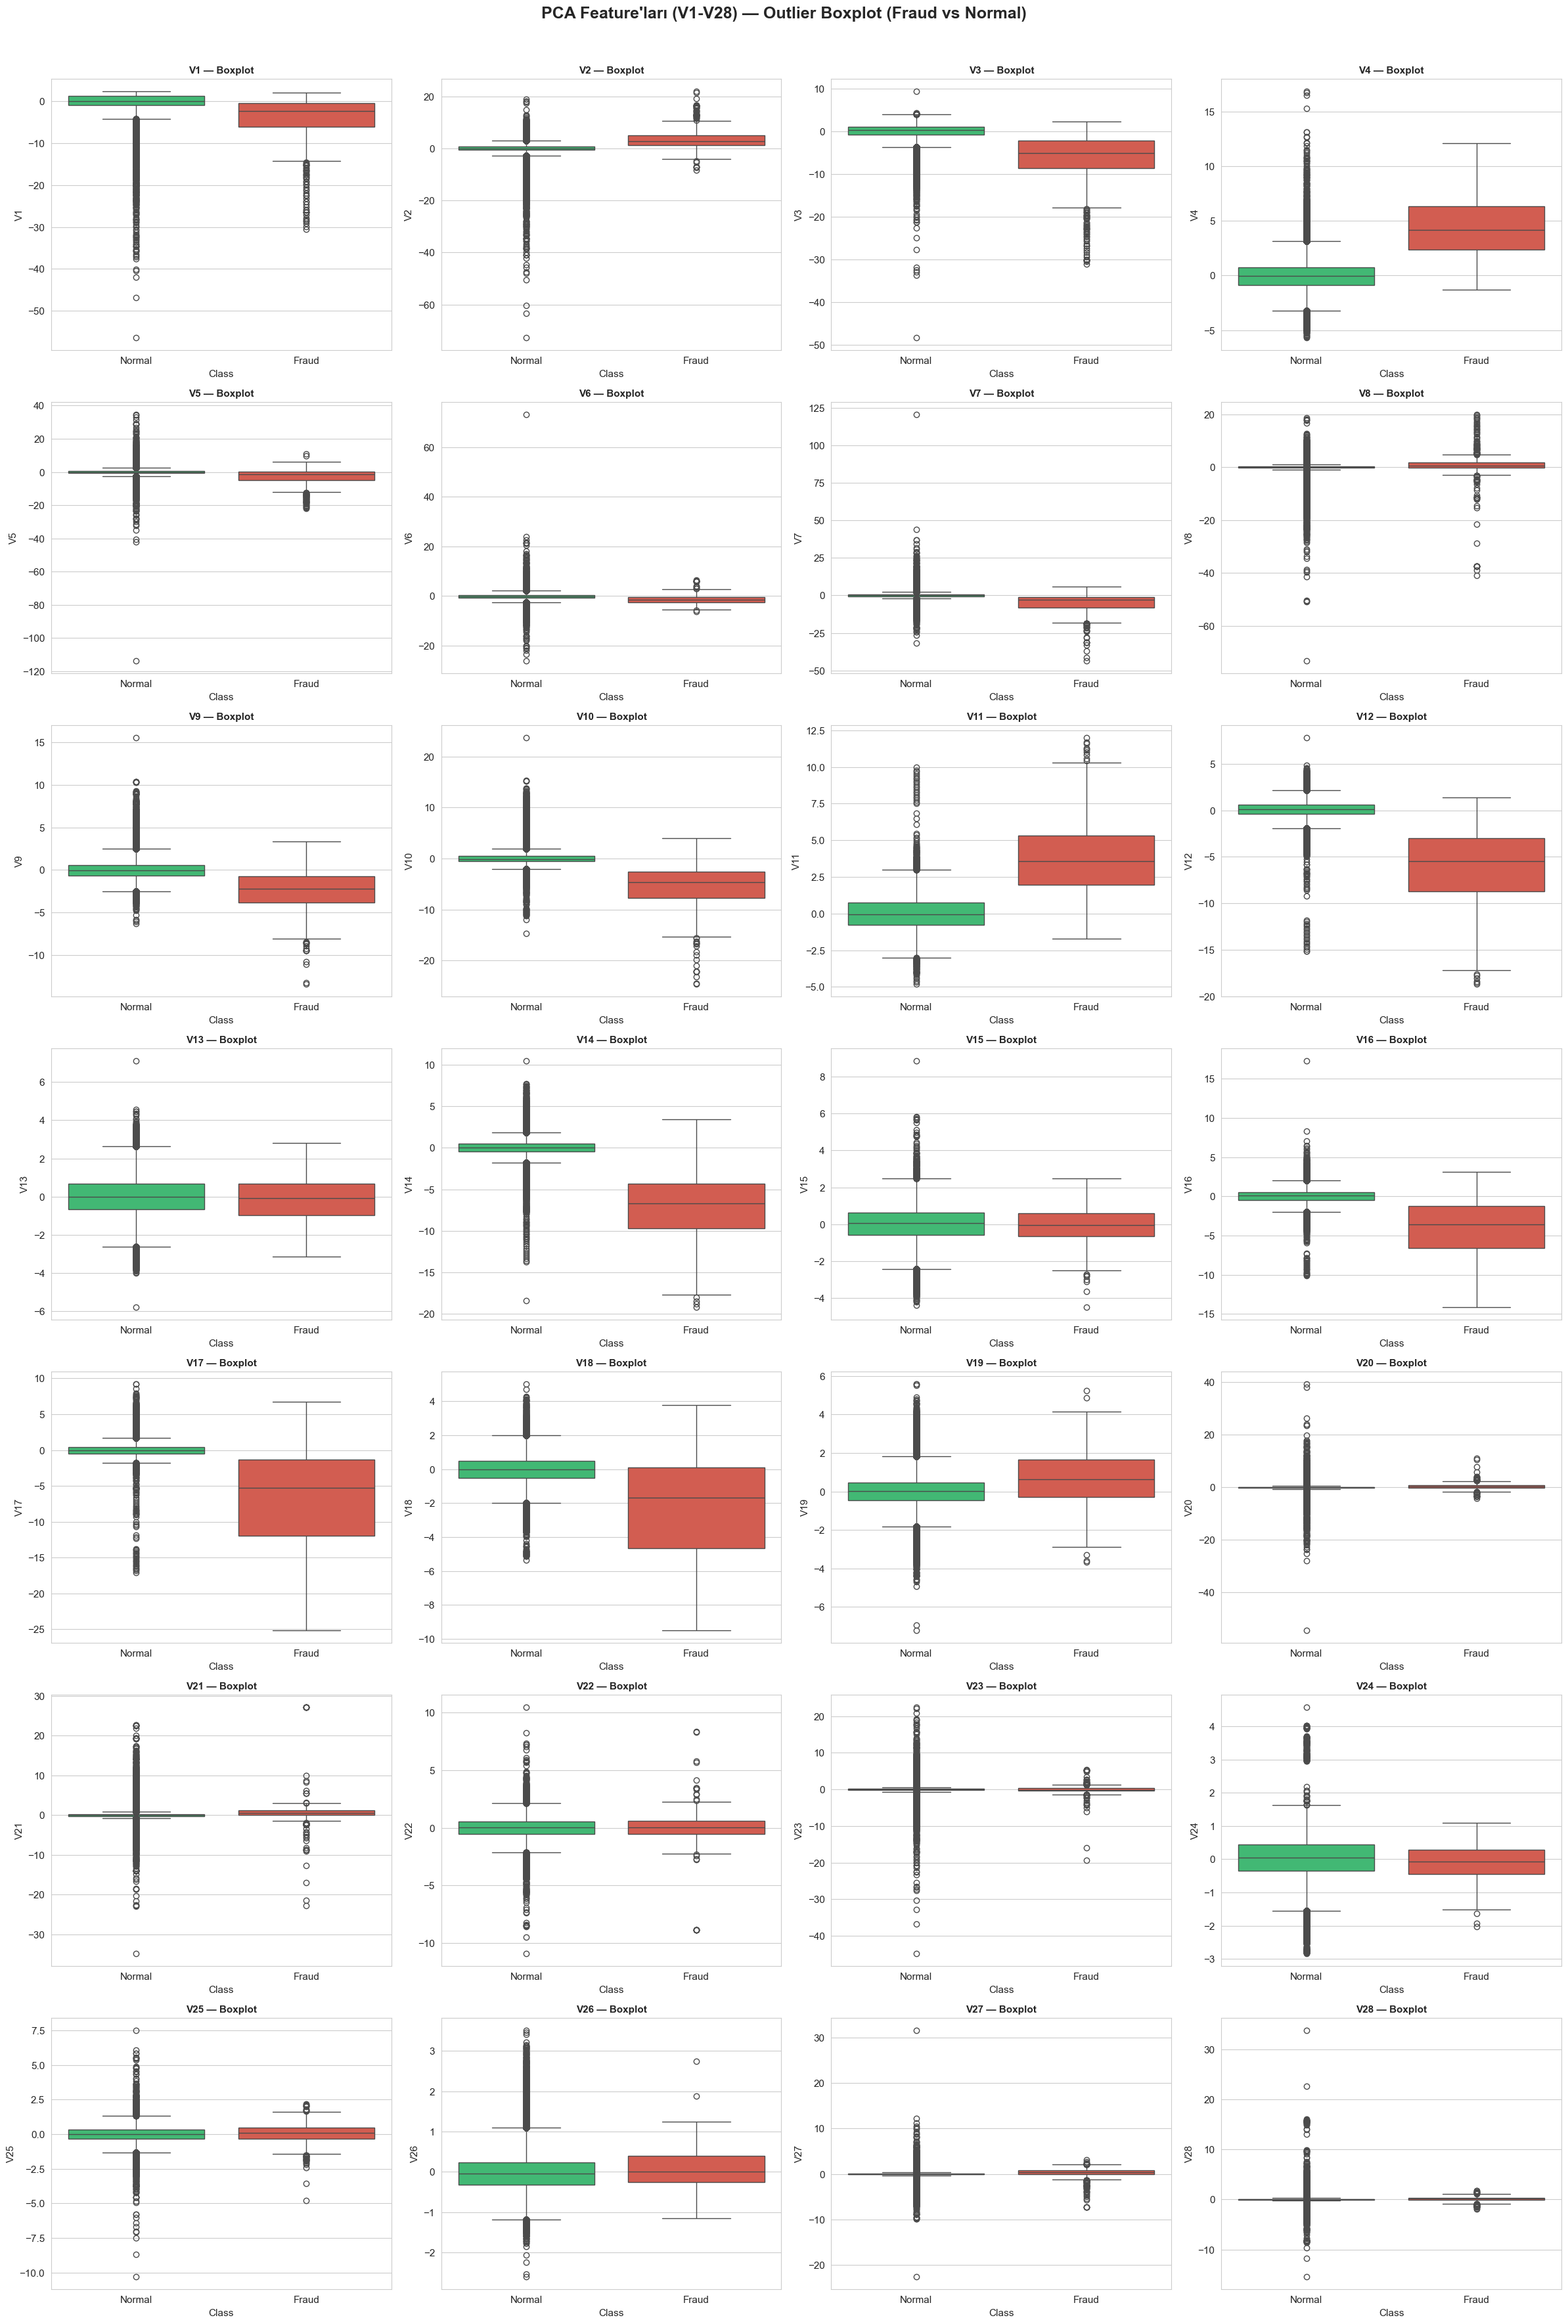

In [89]:
# PCA feature'ları için boxplot grid
fig, axes = plt.subplots(7, 4, figsize=(24, 35))
axes = axes.flatten()

for i, col in enumerate(pca_features):
    sns.boxplot(x='Class', y=col, data=df, ax=axes[i], palette=colors)
    axes[i].set_title(f'{col} — Boxplot', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Normal', 'Fraud'])

plt.suptitle('PCA Feature\'ları (V1-V28) — Outlier Boxplot (Fraud vs Normal)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

*PCA'lı featureların bazılarının aralığını çok kısa tutulup, outlierlarının fazla olduğunu, yani kapsamının az olduğunu görebiliyoruz. Yine de veri sayımızın çok fazla olduğu düşünüldüğünde bu abes gelmiyor. Outlierları cliplemenin yanlış olacağını görüyoruz sadece. Aynı zamanda genellikle fraudların daha dengeli ve geniş yayıldığı, yani daha az outlier yaptığını, yani belirli ortalama ve patternlerde yapıldıklarını çıkartabiliriz.*

---
## Phase I: 5-CV Lasso ile Feature Importance

In [90]:
# 5-fold CV Lasso
X = df.drop('Class', axis=1)
y = df['Class']

# Standardize features for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"En iyi alpha: {lasso_cv.alpha_:.6f}")
print(f"\nFeature Katsayıları (Lasso):")

lasso_coefs = pd.Series(np.abs(lasso_cv.coef_), index=X.columns).sort_values(ascending=False)
print(lasso_coefs)

En iyi alpha: 0.001179

Feature Katsayıları (Lasso):
V17       0.012379
V14       0.011385
V12       0.009642
V10       0.007827
V16       0.006983
V3        0.006834
V7        0.006597
V11       0.005252
V4        0.004362
V18       0.003450
V1        0.003029
V9        0.002879
V5        0.002765
V2        0.002612
V6        0.000633
V21       0.000499
V19       0.000265
Time      0.000000
V13       0.000000
V8        0.000000
V15       0.000000
V20       0.000000
V22       0.000000
V23       0.000000
V24       0.000000
V25       0.000000
V26       0.000000
V27       0.000000
V28       0.000000
Amount    0.000000
dtype: float64


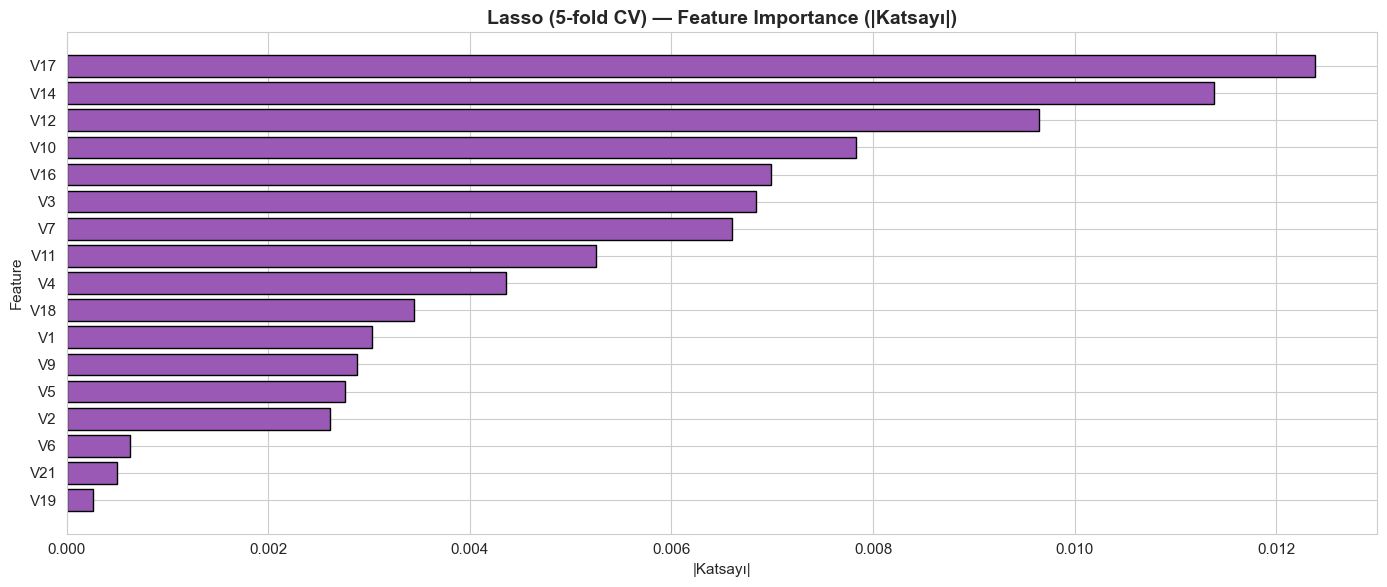


Lasso'ya göre en önemli 5 feature:
         V17: 0.012379
         V14: 0.011385
         V12: 0.009642
         V10: 0.007827
         V16: 0.006983


In [91]:
# Lasso feature importance bar chart
plt.figure(figsize=(14, 6))
lasso_coefs_sorted = lasso_coefs.sort_values(ascending=True)
nonzero = lasso_coefs_sorted[lasso_coefs_sorted > 0]

plt.barh(nonzero.index, nonzero.values, color='#9b59b6', edgecolor='black')
plt.title('Lasso (5-fold CV) — Feature Importance (|Katsayı|)', fontsize=14, fontweight='bold')
plt.xlabel('|Katsayı|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Lasso'ya göre ilk 5 feature
top5_lasso = lasso_coefs.head(5)
print("\nLasso'ya göre en önemli 5 feature:")
for feat, val in top5_lasso.items():
    print(f"  {feat:>10s}: {val:.6f}")

*Yorumunuzu buraya yazın...*

In [92]:
# Heatmap Top 5 vs Lasso Top 5 Karşılaştırma
print("=" * 60)
print("HEATMAP (KORELasyon) vs LASSO — İLK 5 FEATURE KARŞILAŞTIRMA")
print("=" * 60)

comparison = pd.DataFrame({
    'Sıra': range(1, 6),
    'Heatmap (|Korelasyon|)': [f"{f} ({v:.4f})" for f, v in top5_corr.items()],
    'Lasso (|Katsayı|)': [f"{f} ({v:.6f})" for f, v in top5_lasso.items()]
})
comparison = comparison.set_index('Sıra')
print(comparison.to_string())

# Ortak feature'lar
common = set(top5_corr.index) & set(top5_lasso.index)
print(f"\nHer iki yöntemde de ortak olan feature'lar: {common if common else 'Yok'}")

HEATMAP (KORELasyon) vs LASSO — İLK 5 FEATURE KARŞILAŞTIRMA
     Heatmap (|Korelasyon|) Lasso (|Katsayı|)
Sıra                                         
1              V17 (0.3265)    V17 (0.012379)
2              V14 (0.3025)    V14 (0.011385)
3              V12 (0.2606)    V12 (0.009642)
4              V10 (0.2169)    V10 (0.007827)
5              V16 (0.1965)    V16 (0.006983)

Her iki yöntemde de ortak olan feature'lar: {'V17', 'V16', 'V12', 'V14', 'V10'}


*Lasso'da da korelasyon matrisinde de genellikle Amount ve Time gibi featurelara kıyasla PCA ediilmiş featureların daha anlamlı olduğunu ve iki karşılaştırmada da ilk beş tamamen aynı çıktığı için bu tespitlerin sağlıklı olduğunu söyleyebiliriz.*

---
## Phase J: Yeni Feature'lar İçin Analiz (Task 2 Feature Engineering Önizleme)

In [93]:
# Yeni feature'ları oluştur
df_new = df.copy()
df_new['Time_in_day'] = df_new['Time'] % 86400
df_new['Amount_log'] = np.log1p(df_new['Amount'])
df_new['Time_Amount'] = df_new['Time'] * df_new['Amount']
df_new['Time_Amount_sq'] = (df_new['Time'] * df_new['Amount']) ** 2
df_new['Amount_per_Time'] = np.where(df_new['Time'] == 0, 0, df_new['Amount'] / df_new['Time'])

new_features = ['Time_in_day', 'Amount_log', 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']

print("Yeni oluşturulan feature'ların ilk 5 satırı:")
df_new[new_features].head(10)

Yeni oluşturulan feature'ların ilk 5 satırı:


,Time_in_day,Amount_log,Time_Amount,Time_Amount_sq,Amount_per_Time
0,0.0,5.014760,0.00,0.0000,0.000000
1,0.0,1.305626,0.00,0.0000,0.000000
2,1.0,5.939276,378.66,143383.3956,378.660000
3,1.0,4.824306,123.50,15252.2500,123.500000
4,2.0,4.262539,139.98,19594.4004,34.995000
5,2.0,1.541159,7.34,53.8756,1.835000
6,4.0,1.790091,19.96,398.4016,1.247500
7,7.0,3.732896,285.60,81567.3600,5.828571
8,7.0,4.545420,652.40,425625.7600,13.314286
9,9.0,1.543298,33.12,1096.9344,0.408889


In [94]:
# Yeni feature'ların describe'ı
df_new[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Time_in_day,284807.0,5.233662e+04,2.104942e+04,0.0,3.815350e+04,5.403900e+04,6.958700e+04,8.639800e+04
Amount_log,284807.0,3.152188e+00,1.656648e+00,0.0,1.887070e+00,3.135494e+00,4.358822e+00,1.015394e+01
Time_Amount,284807.0,8.250908e+06,2.689658e+07,0.0,3.619688e+05,1.753364e+06,6.544746e+06,4.269819e+09
Time_Amount_sq,284807.0,7.915008e+14,3.739106e+16,0.0,1.310214e+11,3.074285e+12,4.283370e+13,1.823136e+19
Amount_per_Time,284807.0,5.231008e-03,7.600556e-01,0.0,6.314052e-05,2.808860e-04,1.070548e-03,3.786600e+02


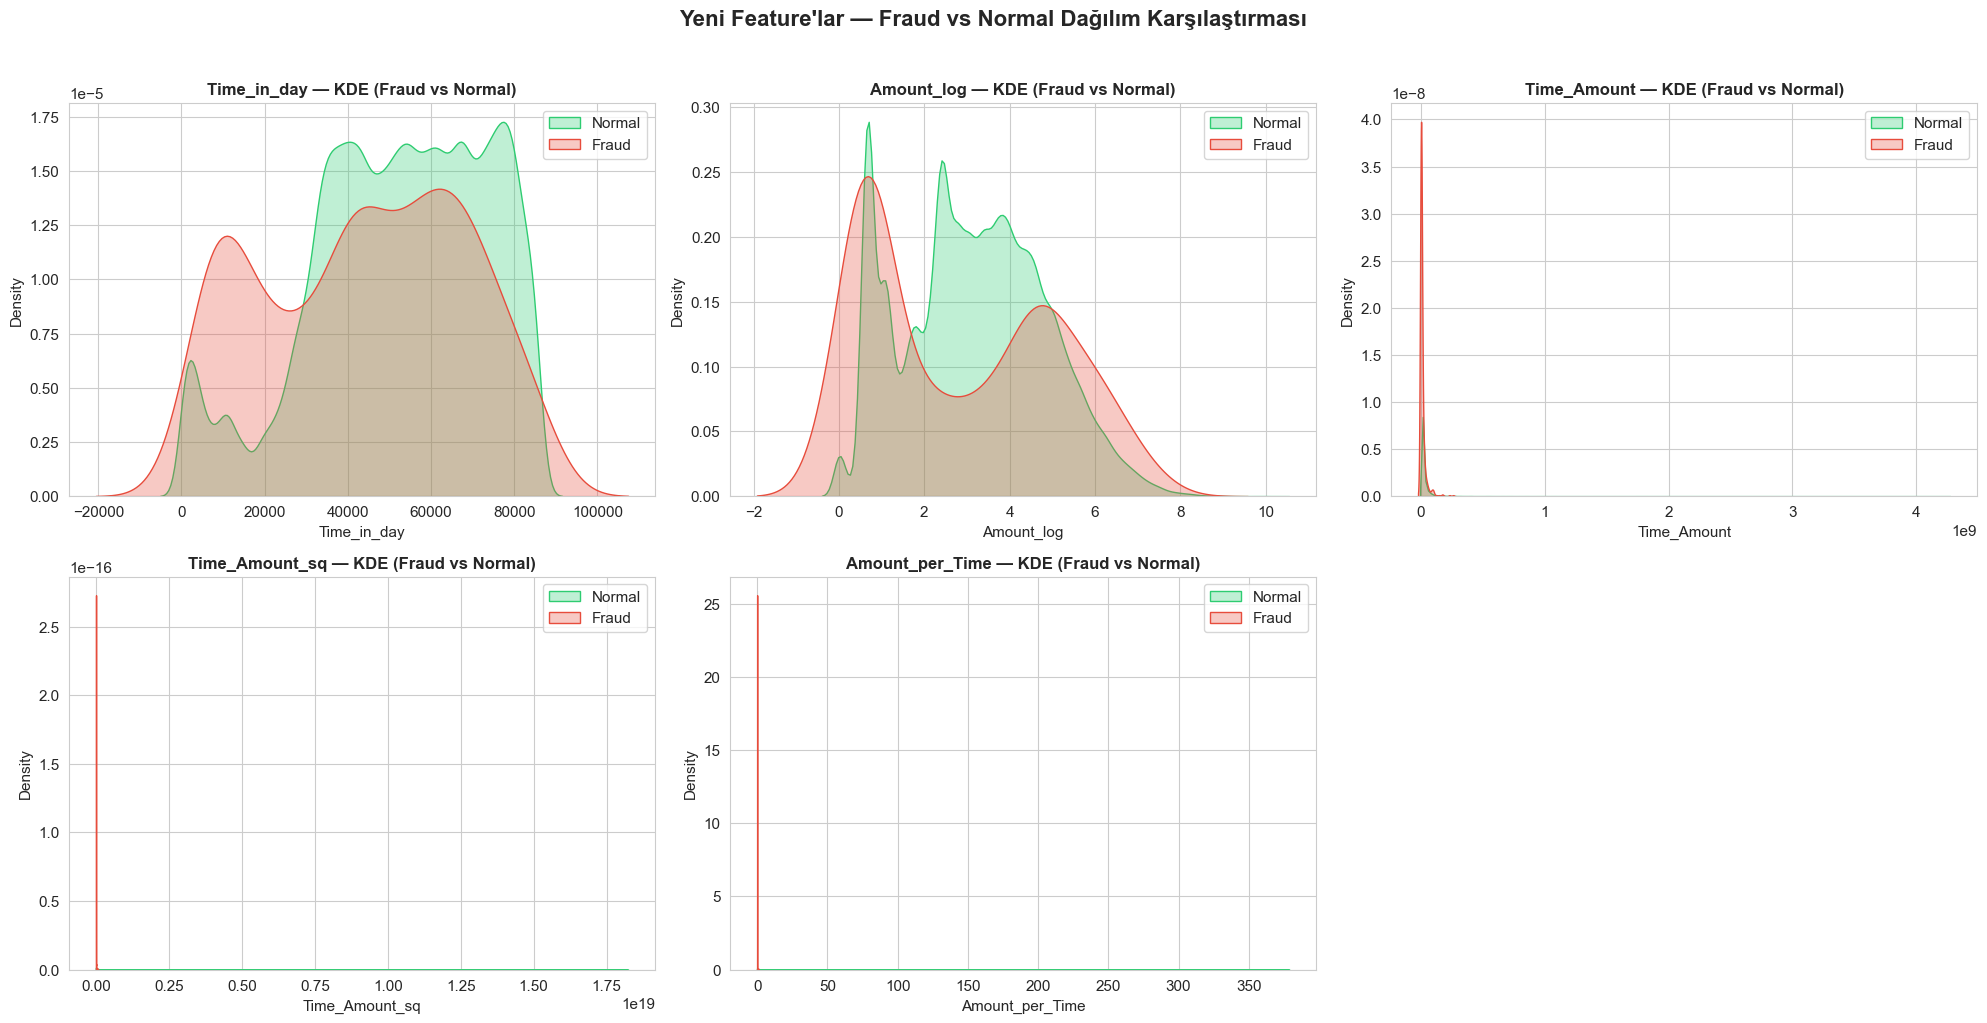

In [95]:
# Yeni feature'ların Fraud vs Normal dağılım KDE plotları
fraud_new = df_new[df_new['Class'] == 1]
normal_new = df_new[df_new['Class'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    sns.kdeplot(normal_new[col], ax=axes[i], label='Normal', color='#2ecc71', fill=True, alpha=0.3)
    sns.kdeplot(fraud_new[col], ax=axes[i], label='Fraud', color='#e74c3c', fill=True, alpha=0.3)
    axes[i].set_title(f'{col} — KDE (Fraud vs Normal)', fontsize=12, fontweight='bold')
    axes[i].legend()

# Boş subplot'u gizle
axes[5].set_visible(False)

plt.suptitle('Yeni Feature\'lar — Fraud vs Normal Dağılım Karşılaştırması',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Sonradan eklenen Zaman x Amount ve türevlerinin çok etkisinin olmadığını kapsamının darlarştığını görebiliyoruz. Time ya da Amount'un birleşmesinden ziyade, kendilerinin türevlerinin alınmasının(matematiksel olan değil çeşitsel olan) daha sağlıklı sonuçlar verdiğini görebiliyoruz. Yani birleştirmekten ziyade var olan featurelardan yeni feature üretmek daha sağlıklı olacaktır.*

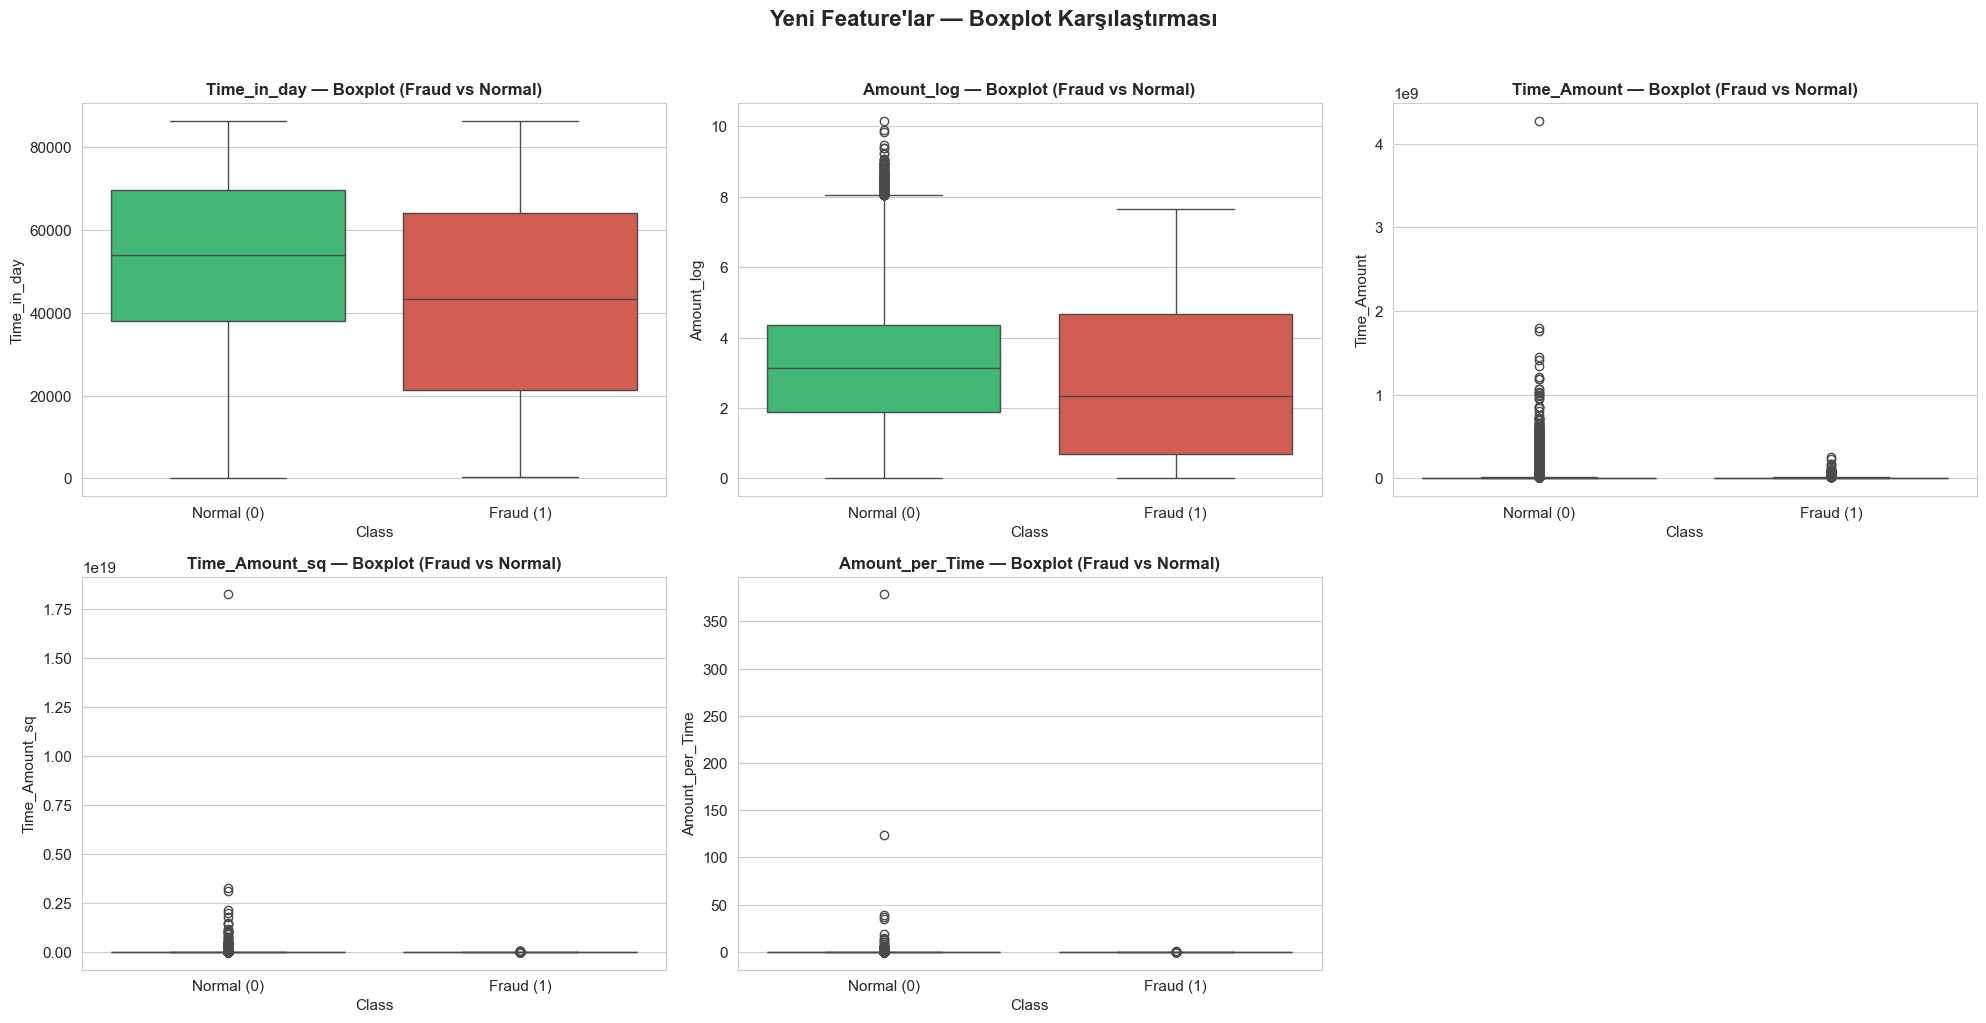

In [96]:
# Yeni feature'ların boxplot'ları (Fraud vs Normal)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    sns.boxplot(x='Class', y=col, data=df_new, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} — Boxplot (Fraud vs Normal)', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Normal (0)', 'Fraud (1)'])

axes[5].set_visible(False)

plt.suptitle('Yeni Feature\'lar — Boxplot Karşılaştırması',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

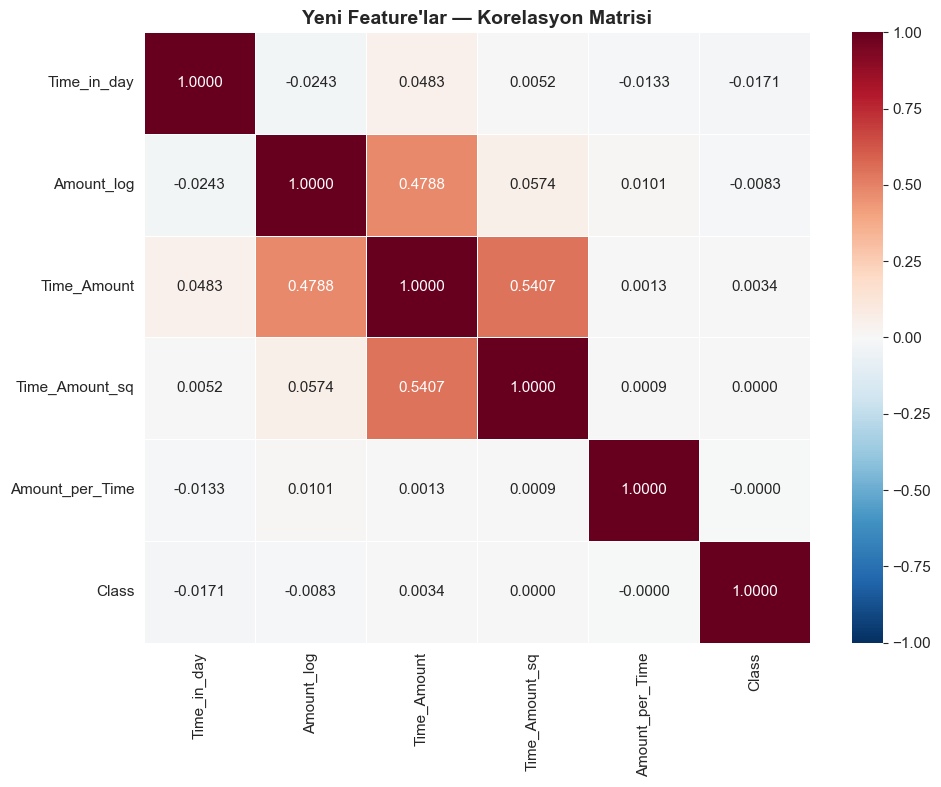


Yeni feature'ların Class ile korelasyonu:
           Time_in_day: -0.0171
            Amount_log: -0.0083
           Time_Amount: +0.0034
       Amount_per_Time: -0.0000
        Time_Amount_sq: +0.0000


In [97]:
# Yeni feature'ların korelasyon analizi (Class ile)
new_corr = df_new[new_features + ['Class']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(new_corr, annot=True, fmt='.4f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Yeni Feature\'lar — Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYeni feature'ların Class ile korelasyonu:")
class_corr_new = new_corr['Class'].drop('Class').abs().sort_values(ascending=False)
for feat, val in class_corr_new.items():
    direction = '+' if new_corr['Class'][feat] > 0 else '-'
    print(f"  {feat:>20s}: {direction}{val:.4f}")

*Class ile korelasyonunun az olması, ve kendi içlerinde korelasyonun yükselmiş olması, yeni featureların kendi içlerinde birbirlerini tekrar ettiğini gösterdiği gibi, bknz:V17: -0.3265, zaten var olan featurelara kıyasla tahmine etkisinin çok az olduğunu görüp bu featureları üretmenin az biraz performansı iyileştirebilse de genel olarak anlamsız ve gereksiz işlem olduğunu göstermekte.*

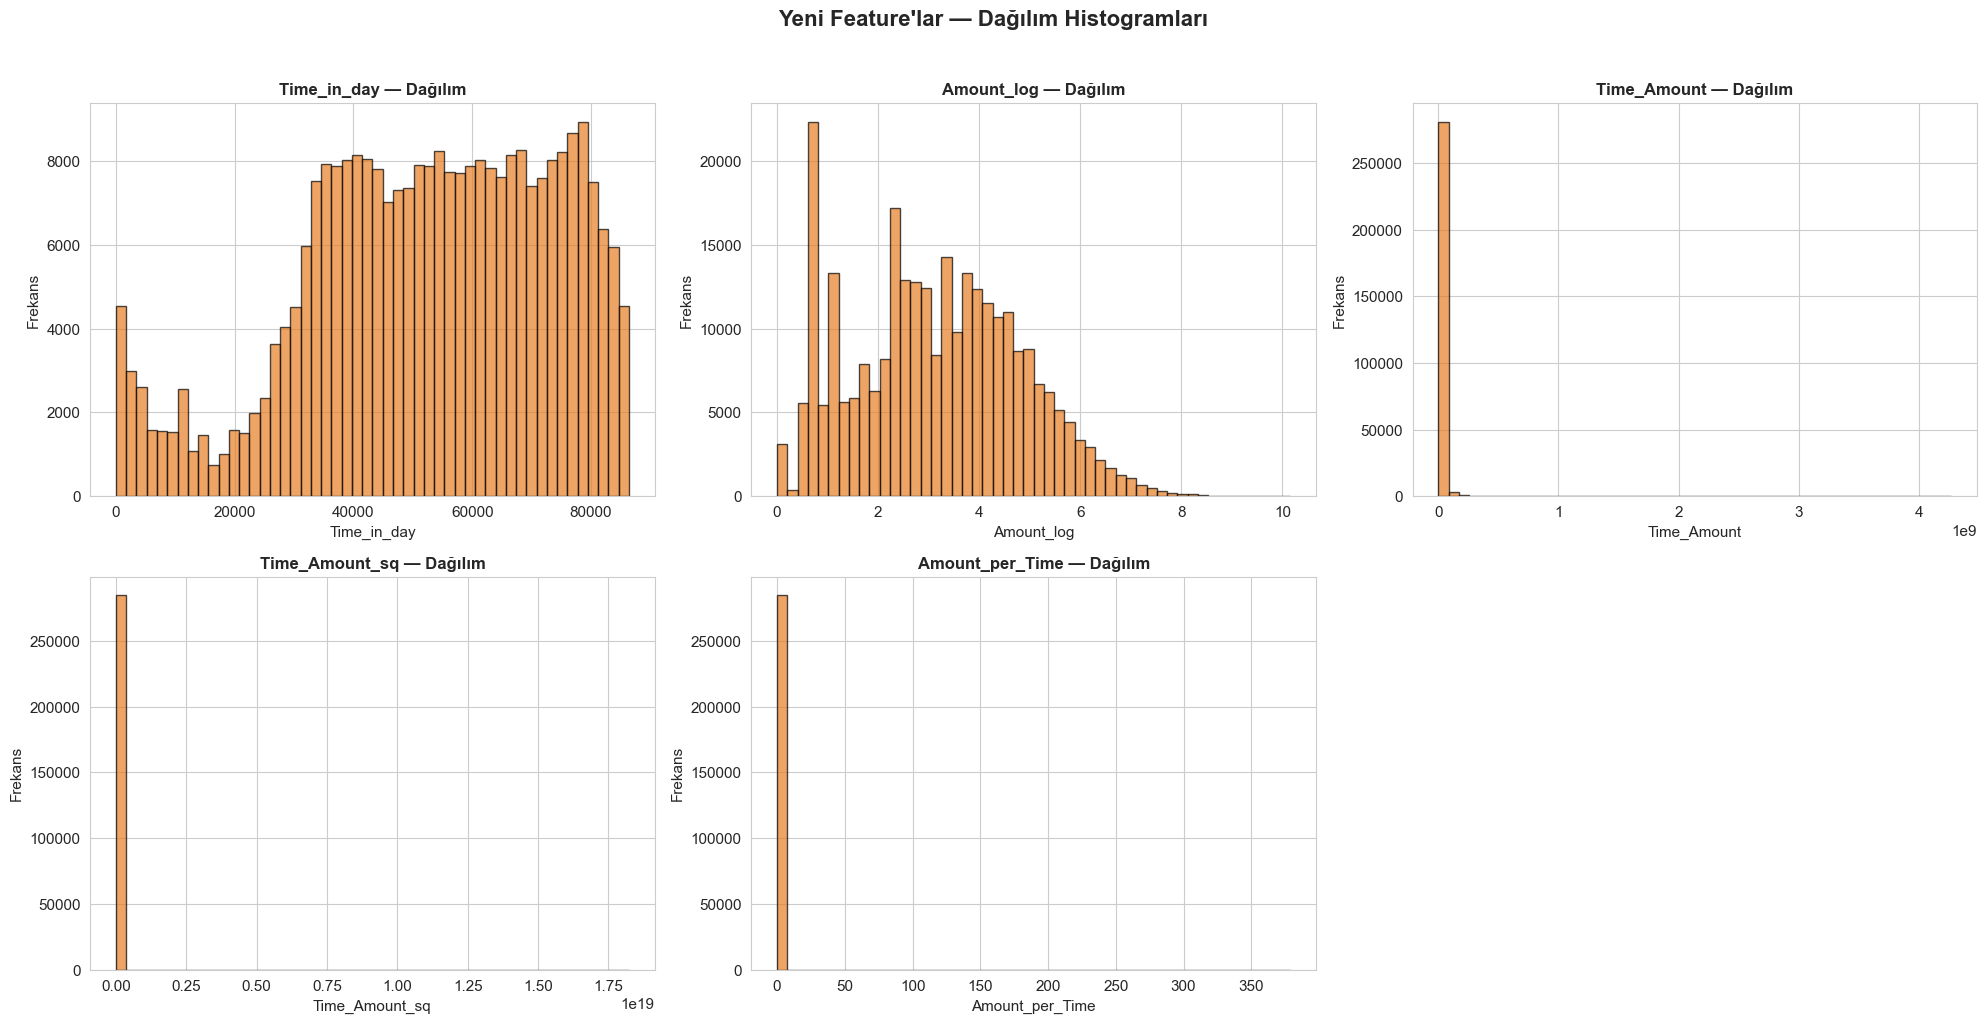

In [98]:
# Yeni feature'ların dağılım histogramları
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    axes[i].hist(df_new[col], bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} — Dağılım', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')

axes[5].set_visible(False)

plt.suptitle('Yeni Feature\'lar — Dağılım Histogramları',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Genellikle time ve amount grafiklerine uyduğunu görüyoruz, ufak istisnalar bknz: amount log'da başta peak yapması gibi, hariç.*

In [99]:
# Yeni feature'lar için IQR tabanlı outlier analizi
new_outlier_summary = []

for col in new_features:
    q1 = df_new[col].quantile(0.25)
    q3 = df_new[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    n_outliers = len(df_new[(df_new[col] < lb) | (df_new[col] > ub)])
    pct = n_outliers / len(df_new) * 100
    new_outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 4),
        'Q3': round(q3, 4),
        'IQR': round(iqr, 4),
        'Alt Sınır': round(lb, 4),
        'Üst Sınır': round(ub, 4),
        'Outlier Adet': n_outliers,
        'Outlier %': round(pct, 2)
    })

new_outlier_df = pd.DataFrame(new_outlier_summary)
new_outlier_df = new_outlier_df.sort_values('Outlier Adet', ascending=False)
print("=" * 80)
print("YENİ FEATURE'LAR — IQR TABANLI OUTLIER TABLOSU")
print("=" * 80)
new_outlier_df

YENİ FEATURE'LAR — IQR TABANLI OUTLIER TABLOSU


,Feature,Q1,Q3,IQR,Alt Sınır,Üst Sınır,Outlier Adet,Outlier %
3,Time_Amount_sq,1.310214e+11,4.283370e+13,4.270268e+13,-6.392299e+13,1.068877e+14,49778,17.48
4,Amount_per_Time,1.000000e-04,1.100000e-03,1.000000e-03,-1.400000e-03,2.600000e-03,35659,12.52
2,Time_Amount,3.619688e+05,6.544746e+06,6.182777e+06,-8.912197e+06,1.581891e+07,33798,11.87
1,Amount_log,1.887100e+00,4.358800e+00,2.471800e+00,-1.820600e+00,8.066500e+00,245,0.09
0,Time_in_day,3.815350e+04,6.958700e+04,3.143350e+04,-8.996750e+03,1.167372e+05,0,0.00
